## Импорты

In [2]:
import contextlib
import io
import json
import operator
import os
import re
import subprocess
import traceback
import warnings
from pathlib import Path
from typing import Annotated, Any, Literal, Optional, TypedDict
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from pydantic import BaseModel, Field, ValidationError

from langchain.agents import create_agent
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send

pd.set_option("display.max_columns", 100)
warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
load_dotenv()

True

In [4]:
API_KEY = os.getenv("OPENROUTER_API_KEY")
print(f"API Key: {API_KEY is not None}")

API Key: True


## Обьявляем все ЛЛМ

### Описание

In [5]:
model = "deepseek/deepseek-v4-flash"
# model = 'google/gemma-4-26b-a4b-it'
model = 'openai/gpt-4.1-mini'
model = 'google/gemini-3-flash-preview'

llm_descr = ChatOpenAI(
    model = model,
    api_key = API_KEY,
    base_url = "https://openrouter.ai/api/v1",
    temperature = 0,
    max_tokens = 5000
)

In [6]:
@tool
def python_interpreter_tool(code: str):
    """
    Выполняет Python-код и возвращает stdout, ошибку и статус
    Запрещено:
    - удалять файлы и папки
    - использовать subprocess
    - использовать сетевые запросы
    - использовать requests, urllib, socket
    - менять исходный датасет
    """


    lowered_code = code.lower()

    local_memory = {}
    stdout_buffer = io.StringIO()

    try:
        with contextlib.redirect_stdout(stdout_buffer):
            exec(code, local_memory, local_memory)

        return {
            "status": "success",
            "stdout": stdout_buffer.getvalue()[:5000],
            "error": None,
        }

    except Exception:
        return {
            "status": "failed",
            "stdout": stdout_buffer.getvalue()[:5000],
            "error": traceback.format_exc(),
        }

In [7]:

DATA_DESCRIPTION_STAGE_PROMPT = """
Ты - агент описания данных в мультиагентной системе

Твоя задача:
- анализировать датасет пошагово;
- выполнять только тот этап, который сейчас запрошен оркестратором;
- возвращать результат строго в JSON.

Правила:
- Ты можешь использовать python_interpreter_tool для выполнения кода
- Пиши короткий код на Python только для текущего этапа
- Не выполняй несколько этапов пайплайна за один раз
- Не выполняй предобработку данных
- Не обучай модели
- Не изменяй исходный датасет
- Используй только pandas, numpy, json, pathlib, re, collections
- Возвращай только валидный JSON для текущего этапа
- Не пиши код в финальный ответ пиши только JSON
- Не используй markdown
- Не добавляй объяснения вне JSON
"""

data_description_stage_agent = create_agent(
    model=llm_descr,
    tools=[python_interpreter_tool],
    system_prompt=DATA_DESCRIPTION_STAGE_PROMPT,
)

### Подготовка данных

In [8]:
model = "deepseek/deepseek-v4-flash"
# model = 'google/gemma-4-26b-a4b-it'
model = 'openai/gpt-4.1-mini'
model = 'google/gemini-3-flash-preview'
# model = 'openai/gpt-5.4-mini'

llm_prep = ChatOpenAI(
    model = model,
    api_key = API_KEY,
    base_url = "https://openrouter.ai/api/v1",
    temperature = 0,
    max_tokens = 5000
)

In [9]:
DATA_PREPARATION_STAGE_PROMPT = """
Ты - агент подготовки данных в мультиагентной системе

Твоя задача:
- готовить датасет пошагово
- выполнять только тот этап, который сейчас запрошен оркестратором
- возвращать результат строго в JSON

Правила:
- Ты можешь использовать python_interpreter_tool для выполнения кода
- Пиши короткий код на Python только для текущего этапа
- Не выполняй несколько этапов пайплайна за один раз
- Не делай полный EDA
- Не обучай модели
- Не изменяй исходный датасет
- Используй только pandas, numpy, json, pathlib, re, collections
- Используй schema которую передал оркестратор, как основной источник истины
- Не переопределяй типы признаков, если текущий этап явно не просит их проверить
- НИКОГДА НЕ используй target column для feature engineering и не меняй target column ничем
- Возвращай только валидный JSON для текущего этапа
- Не пиши код в финальный ответ пиши только JSON
- Не используй markdown
- Не добавляй объяснения вне JSON
"""

data_preparation_stage_agent = create_agent(
    model=llm_prep,
    tools=[python_interpreter_tool],
    system_prompt=DATA_PREPARATION_STAGE_PROMPT,
)

### Обучатор моделей

In [10]:
model = "deepseek/deepseek-v4-flash"
# model = 'google/gemma-4-26b-a4b-it'
model = 'openai/gpt-4.1-mini'
model = 'google/gemini-3-flash-preview'
# model = 'openai/gpt-5.4-mini'

llm_model = ChatOpenAI(
    model = model,
    api_key = API_KEY,
    base_url = "https://openrouter.ai/api/v1",
    temperature = 0,
    max_tokens = 5000
)

In [11]:
MODELING_STAGE_PROMPT = """
Ты - агент, который обучаем модели машинного обучения и оценивает их

Твоя задача:
- обучать и оценивать модели машинного обучения пошагово
- выполнять только тот этап, который сейчас запрошен 
- возвращать результат строго в JSON

Правила:
- Ты можешь использовать python_interpreter_tool для выполнения кода
- Пиши короткий код на Python только для текущего этапа
- Не выполняй несколько этапов пайплайна за один раз
- Не выполняй подготовку данных
- Не обучай модели
- Не изменяй исходный подготовленный датасет
- Используй только pandas, numpy, json, pathlib, sklearn, joblib.
- Используй prepared dataset path, переданный оркестратором.
- Используй target column как целевую переменную
- Используй task type но он скорее всего будет regression
- Не используй target column как признак
- Сохраняй model artifacts только по пути, который запросил оркестратор
- Возвращай только валидный JSON для текущего этапа
- Не пиши код в финальный ответ пиши только JSON
- Не используй markdown
- Не добавляй объяснения вне JSON
"""

modeling_stage_agent = create_agent(
    model=llm_model,
    tools=[python_interpreter_tool],
    system_prompt=MODELING_STAGE_PROMPT,
)

### Сообщатор

In [12]:
REPORTING_AGENT_PROMPT = """
Ты — агент, который создает финальный отчет по проекту

Твоя задача:
- создать финальный отчет на основе результатов предыдущих агентов
- использовать только уже полученные summary и artifacts
- сохранить отчет в Markdown файл
- вернуть результат строго в JSON

Правила:
- Ты можешь использовать python_interpreter_tool для записи файла отчета
- Не обучай модели
- Не изменяй датасеты
- Не выполняй подготовку данных
- Не используй интернет или внешние API
- Используй только json, pathlib, pandas если нужно
- Пиши отчет понятным Markdown
- Включи техническую интерпретацию результатов
- Включи бизнес интерпретацию результатов
- Используй только переданные summary и artifacts
- Не придумывай метрики
- Если какой-то информации нет, пиши "not available"
- Возвращай только валидный JSON
- Не пиши код в финальный ответ, пиши только JSON
- Не включай tool calls, tool code, stdout или debug output в финальный ответ
- Не используй markdown вне файла отчета
- Не добавляй объяснения вне JSON
"""

In [13]:
model = "deepseek/deepseek-v4-flash"
# model = 'google/gemma-4-26b-a4b-it'
model = 'openai/gpt-4.1-mini'
model = 'google/gemini-3-flash-preview'
# model = 'openai/gpt-5.4-mini'

llm_reporting = ChatOpenAI(
    model = model,
    api_key = API_KEY,
    base_url = "https://openrouter.ai/api/v1",
    temperature = 0,
    max_tokens = 5000
)
reporting_agent = create_agent(
    model=llm_reporting,
    tools=[python_interpreter_tool],
    system_prompt=REPORTING_AGENT_PROMPT,
)

### Оркестратор

In [14]:
ORCHESTRATOR_SYSTEM_PROMPT = """
Ты — LLM-оркестратор в мультиагентной системе.

Твоя роль:
- анализировать текущий AgentState
- решать, что должно произойти дальше
- выбирать, какого специализированного агента нужно вызвать
- кратко объяснять причину решения
- обрабатывать ошибки, повторные попытки и завершение workflow
- использовать dataset_path, найденный на этапе инициализации
- использовать previous_best_model_path и previous_metrics_path, найденные на этапе инициализации, если они есть

Ты НЕ обучаешь модели напрямую.
Ты НЕ делаешь предобработку данных напрямую.
Ты НЕ создаёшь отчёты напрямую.
Ты только управляешь workflow.

Инициализация перед запуском оркестратора:
До запуска orchestrator_agent граф уже должен выполнить:
1. dataset_finder
2. previous_run_finder
3. join_init

Оркестратор не должен напрямую вызывать dataset_finder или previous_run_finder.
Если после инициализации dataset_path отсутствует, выбери fail.

Доступные решения:
- run_data_description
- run_data_preparation
- run_modeling
- run_reporting
- finish
- fail

Специализированные агенты:
- data_description_agent
- data_preparation_agent
- modeling_agent
- reporting_agent

Текущий workflow:
0. Инициализация уже выполнена до оркестратора:
   - dataset_finder
   - previous_run_finder
   - join_init
1. data_description_agent
2. data_preparation_agent
3. modeling_agent
4. reporting_agent

Правило про предыдущий запуск:
- Наличие предыдущего запуска НЕ означает, что текущий workflow уже выполнен.
- Не пропускай текущее моделирование только потому, что предыдущий запуск существует.
- Не выбирай finish только потому, что предыдущий запуск существует.
- previous_best_model_path и previous_metrics_path можно использовать только как контекст для сравнения, отчёта или fallback-комментариев.
- Текущий modeling_agent считается выполненным только по текущим modeling_summary и artifacts.

Шаг считается выполненным ТОЛЬКО по следующим правилам:

1. data_description_agent выполнен, если:
   - data_description["status"] == "success"
   ИЛИ выполнены все условия:
   - data_summary содержит "n_rows"
   - data_summary содержит "n_columns"
   - schema содержит "numeric"
   - schema содержит "categorical"
   - schema содержит "text"
   - schema содержит "datetime"

2. data_preparation_agent выполнен, если:
   - data_preparation["status"] == "success"
   - artifacts["prepared_dataset_path"] != null

3. modeling_agent выполнен, если:
   - modeling_summary["status"] == "success"
   - modeling_summary["best_model_name"] != null
   - artifacts["best_model_path"] != null

4. reporting_agent выполнен, если:
   - final_report["status"] == "success"
   ИЛИ:
   - artifacts["final_report_path"] != null

Правило failed + retry:
- Если этап имеет status == "failed", этот этап считается НЕ выполненным.
- Если этап завершился failed и число retry для этого этапа меньше max_retries, выбери решение, которое заново запускает этот же этап:
  - data_description_agent failed → decision = "run_data_description"
  - data_preparation_agent failed → decision = "run_data_preparation"
  - modeling_agent failed → decision = "run_modeling"
  - reporting_agent failed → decision = "run_reporting"
- При повторном запуске добавь новую запись в retry_history.
- Количество retry считай по retry_history для конкретного агента.
- Если число retry для failed-этапа уже достигло max_retries, выбери fail.
- Не переходи к следующему этапу, если предыдущий этап failed и ещё доступна retry-попытка.

Как определить failed-этап:
- data_description_agent failed, если data_description["status"] == "failed" или последний лог data_description_agent имеет status == "failed".
- data_preparation_agent failed, если data_preparation["status"] == "failed" или последний лог data_preparation_agent имеет status == "failed".
- modeling_agent failed, если modeling_summary["status"] == "failed" или последний лог modeling_agent имеет status == "failed".
- reporting_agent failed, если final_report["status"] == "failed" или последний лог reporting_agent имеет status == "failed".

Порядок принятия решения:
1. Если dataset_path отсутствует или равен null, выбери fail.
2. Если есть failed-этап и retry для него ещё доступен, выбери run_* этого же этапа и добавь запись в retry_history.
3. Если есть failed-этап и retry для него уже исчерпан, выбери fail.
4. Если error не равен null и можно определить failed/current этап, выбери run_* этого же этапа и добавь запись в retry_history.
5. Если error не равен null и retry уже исчерпан, выбери fail.
6. Если data_description_agent не выполнен, выбери run_data_description.
7. Иначе если data_preparation_agent не выполнен, выбери run_data_preparation.
8. Иначе если modeling_agent не выполнен, выбери run_modeling.
9. Иначе если reporting_agent не выполнен, выбери run_reporting.
10. Иначе выбери finish.

Строгие правила:
- Не придумывай дополнительные требования к завершению шагов.
- Не выбирай следующий этап, если предыдущий этап failed и ещё можно сделать retry.
- Не выбирай run_data_description, если data_description["status"] == "success" или data_summary/schema содержат completion-ключи.
- Не выбирай run_data_preparation, если data_preparation["status"] == "success" и prepared_dataset_path существует.
- Не выбирай run_modeling до завершения data_preparation_agent.
- Modeling можно запускать только после появления prepared_dataset_path.
- Не выбирай run_reporting до завершения modeling_agent.
- Не выбирай fail, если error == null, нет failed-этапа с исчерпанными retry и dataset_path существует.
- Никогда не используй устаревшие решения: retry_current_step, run_tabular_preparation, run_text_preparation, merge_features, run_improvement, use_fallback.
- Никогда не используй устаревших агентов: tabular_preparation_agent, text_preparation_agent, merge_features, improvement_agent.
- Когда требуется структурированное решение, возвращай только валидный JSON.

Формат retry_history:
Если retry не нужен:
"retry_history": []

Если retry нужен:
"retry_history": [
  {
    "agent": "modeling_agent",
    "failed_step": "modeling_agent",
    "retry_number": 1,
    "error": "краткое описание ошибки",
    "decision": "run_modeling"
  }
]

Обязательный JSON-формат:
{
  "decision": "одно из доступных решений",
  "reason": "краткая причина решения",
  "selected_agent": "один из доступных специализированных агентов или null",
  "retry_history": []
}
"""

In [15]:
model = "deepseek/deepseek-v4-flash"
# model = 'google/gemma-4-26b-a4b-it'
model = 'google/gemini-3-flash-preview'
# model = 'openai/gpt-5.4-mini'

llm_orchestrator = ChatOpenAI(
    model = model,
    api_key = API_KEY,
    base_url = "https://openrouter.ai/api/v1",
    temperature = 0,
    max_tokens = 5000
)

In [16]:
@tool
def bash_tool(command: str):
    """
    Выполняет bash команду и возвращает stdout, stderr и return code
    Используй этот инструмент только для безопасной проверки файловой системы:
    - найти CSV-файлы
    - посмотреть список файлов и папок
    - прочитать JSON-файлы
    - проверить существование файла
    Не используй этот инструмент для удаления, перемещения,
    перезаписи или изменения файлов
    """

    try:
        result = subprocess.run(
            command,
            shell=True,
            capture_output=True,
            text=True,
            timeout=30,
        )

        return {
            "status": "success" if result.returncode == 0 else "failed",
            "stdout": result.stdout.strip(),
            "stderr": result.stderr.strip(),
            "returncode": result.returncode,
        }

    except Exception as e:
        return {
            "status": "failed",
            "stdout": "",
            "stderr": str(e),
            "returncode": -1,
        }

In [17]:
tools = [bash_tool]

orchestrator_tool_agent = create_agent(
    model=llm_orchestrator,
    tools=tools,
    system_prompt=ORCHESTRATOR_SYSTEM_PROMPT,
)

## Оркестратор

In [18]:
class AgentState(TypedDict, total=False):
    run_id: str | None

    dataset_path: str | None
    prepared_dataset_path: str | None

    target_column: str | None
    task_type: Literal["classification", "regression", "auto"]

    schema: dict[str, list[str]]
    data_summary: dict[str, Any]

    prep_summary: dict[str, Any]
    data_preparation: dict[str, Any]

    modeling_summary: dict[str, Any]

    next_input: dict[str, Any]

    artifacts: dict[str, str | None]
    logs: Annotated[list[dict[str, Any]], operator.add]

    current_step: str | None
    next_action: str | None
    orchestration_decision: dict[str, Any]
    orchestration_history: Annotated[list[dict[str, Any]], operator.add]

    previous_best_model_path: str | None
    previous_metrics_path: str | None

    retry_history: Annotated[list[dict[str, Any]], operator.add]
    max_retries: int

    status: str
    error: str | None

In [19]:
def extract_csv_path(text: str) -> str | None:
    match = re.search(r"([./\w\-/]+\.csv)", text)
    if match:
        return match.group(1)
    return None

In [20]:
def dataset_finder_node(state: AgentState):
    print("=== ЗАПУСК ПОИСКА ДАТАСЕТА ===")

    result = orchestrator_tool_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": (
                    "Найди основной CSV-датасет в текущей папке проекта"
                    "При необходимости используй bash_tool"
                    "Предпочитай файлы внутри ./data"
                    "Игнорируй файлы внутри ./artifacts"
                    "Игнорируй predictions.csv, metrics.csv и временные output-файлы"
                    "Верни только путь к датасету обычным текстом"
                    "Не добавляй объяснения"
                )
            }
        ]
    })

    agent_response = result["messages"][-1].content.strip()

    print("Ответ dataset_finder:", agent_response)

    dataset_path = extract_csv_path(agent_response)

    if not dataset_path:
        print("Поиск датасета завершился ошибкой")

        return {
            "error": f"Путь к датасету не найден. {agent_response}",
            "status": "failed",
            "logs": [{
                "agent": "dataset_finder",
                "status": "failed",
                "summary": "Не удалось найтиь датасет",
                "decisions": {
                    "agent_response": agent_response
                },
                "artifacts": {},
                "next_input": {},
                "reason": "Датасет не найден",
            }],
        }

    print(f"Поиск датасета завершён. Путь к датасету: {dataset_path}")

    return {
        "dataset_path": dataset_path,
        "status": "running",
        "error": None,
        "logs": [{
            "agent": "dataset_finder",
            "status": "success",
            "summary": f"Датасет найден: {dataset_path}",
            "decisions": {
                "agent_response": agent_response,
            },
            "artifacts": {},
            "next_input": {
                "dataset_path": dataset_path,
            },
            "reason": None,
        }],
    }

In [21]:
def extract_json_safe(text: str) -> dict | None:
    text = text.strip()

    if text.startswith("```json"):
        text = text.replace("```json", "").replace("```", "").strip()
    elif text.startswith("```"):
        text = text.replace("```", "").strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            return None

    return None

In [22]:
def previous_run_finder_node(state: AgentState) -> AgentState:
    print("=== ПОИСК ПРЕДЫДУЩЕГО ЗАПУСКА ===")

    result = orchestrator_tool_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": (
                    "Найди последний предыдущий ML-запуск внутри папки artifacts"
                    "При необходимости используй bash_tool"
                    "Ищи артефакты, которые могут содержать metrics.json, final_metrics.json, "
                    "best_model.pkl или best_model.joblib"
                    "Сначала проверь текущие modeling-artifacts: "
                        "artifacts/modeling/final_metrics.json, "
                        "artifacts/modeling/best_model.joblib, "
                        "artifacts/modeling/modeling_summary.json. "
                    "Верни только валидный JSON, без markdown и без объяснений"

                    "Формат JSON:\n"
                    "{\n"
                    '  "metrics_path": "path or null",\n'
                    '  "best_model_path": "path or null"\n'
                    "}"
                )
            }
        ]
    })

    agent_response = result["messages"][-1].content.strip()
    print("previous_run_finder:", agent_response)

    parsed = extract_json_safe(agent_response)

    if parsed is None:
        parsed = {
            "metrics_path": None,
            "best_model_path": None,
        }

    metrics_path = parsed.get("metrics_path")
    best_model_path = parsed.get("best_model_path")

    if metrics_path in ["null", "None", ""]:
        metrics_path = None

    if best_model_path in ["null", "None", ""]:
        best_model_path = None

    previous_run_found = bool(metrics_path or best_model_path)

    if not previous_run_found:
        log_record = {
            "agent": "previous_run_finder",
            "status": "success",
            "summary": "Предыдущая лучшая модель или метрики не найдены",
            "decisions": {
                "agent_response": agent_response,
                "previous_best_model_path": None,
                "previous_metrics_path": None,
            },
            "artifacts": {},
            "reason": "Пути к предыдущей модели или метрикам не найдены.",
        }

        return {
            "previous_best_model_path": None,
            "previous_metrics_path": None,
            "logs": [log_record],
        }

    log_record = {
        "agent": "previous_run_finder",
        "status": "success",
        "summary": "Предыдущая лучшая модель или метрики найдены.",
        "decisions": {
            "agent_response": agent_response,
            "previous_best_model_path": best_model_path,
            "previous_metrics_path": metrics_path,
        },
        "artifacts": {},
        "reason": None,
    }

    return {
        "previous_best_model_path": best_model_path,
        "previous_metrics_path": metrics_path,
        "logs": [log_record],
    }

In [23]:
def join_init_node(state: AgentState) -> AgentState:
    print("=== ОБЪЕДИНЕНИЕ ===")

    dataset_path = state.get("dataset_path")
    previous_best_model_path = state.get("previous_best_model_path")
    previous_metrics_path = state.get("previous_metrics_path")

    log_record = {
        "agent": "join_init",
        "status": "success",
        "summary": "Инициализация завершена: поиск датасета и поиск предыдущих артефактов выполнены",
        "decisions": {
            "dataset_path": dataset_path,
            "previous_best_model_path": previous_best_model_path,
            "previous_metrics_path": previous_metrics_path,
        },
        "artifacts": {},
        "reason": None,
    }

    return {
        "current_step": "join_init",
        "logs": [log_record],
    }

In [24]:
class OrchestratorDecision(BaseModel):
    decision: Literal[
        "run_data_description",
        "run_data_preparation",
        "run_modeling",
        "run_reporting",
        "finish",
        "fail",
    ] = Field(
        description="Следующее действие, которое выбрал оркестратор"
    )

    reason: str = Field(
        description="Краткое объяснение, почему выбрано именно это действие"
    )

    selected_agent: Optional[
        Literal[
            "data_description_agent",
            "data_preparation_agent",
            "modeling_agent",
            "reporting_agent",
        ]
    ] = Field(
        default=None,
        description="Название агента, которого нужно вызвать следующим. Для finish и fail должно быть None"
    )

    retry_history: list[dict[str, Any]] = Field(
        default_factory=list,
        description="История retry попыток, если оркестратор решил повторить failed этап"
    )

In [25]:
def route_by_orchestrator_decision(state: AgentState) -> str:
    next_action = state.get("next_action")

    allowed_routes = {
        "run_data_description",
        "run_data_preparation",
        "run_modeling",
        "run_reporting",
        "finish",
        "fail",
    }

    if next_action is None:
        return "fail"

    if next_action not in allowed_routes:
        return "fail"

    return next_action

In [26]:
def call_orchestrator_llm_orchestrator(state: dict) -> OrchestratorDecision:
    """
    Отправляет текущее состояние AgentState в LLM-оркестратор
    и возвращает провалидированный объект OrchestratorDecision.
    """

    state_for_llm_orchestrator = {

        "retry_history": state.get("retry_history", []),
        "run_id": state.get("run_id"),
        "dataset_path": state.get("dataset_path"),
        "target_column": state.get("target_column"),
        "task_type": state.get("task_type"),

        "schema": state.get("schema", {}),
        "data_summary": state.get("data_summary", {}),
        "prep_summary": state.get("prep_summary", {}),
        "data_preparation": state.get("data_preparation", {}),
        "modeling_summary": state.get("modeling_summary", {}),
        "final_report": state.get("final_report", {}),
        "artifacts": state.get("artifacts", {}),

        "previous_best_model_path": state.get("previous_best_model_path"),
        "previous_metrics_path": state.get("previous_metrics_path"),

        "available_keys": {
            "schema_keys": list(state.get("schema", {}).keys()),
            "data_summary_keys": list(state.get("data_summary", {}).keys()),
            "prep_summary_keys": list(state.get("prep_summary", {}).keys()),
            "data_preparation_keys": list(state.get("data_preparation", {}).keys()),
            "modeling_summary_keys": list(state.get("modeling_summary", {}).keys()),
            "final_report_keys": list(state.get("final_report", {}).keys()),
            "artifact_keys": list(state.get("artifacts", {}).keys()),
        },

        "logs_count": len(state.get("logs", [])),
        "current_step": state.get("current_step"),
        "next_action": state.get("next_action"),
        "orchestration_history": state.get("orchestration_history", [])[-5:],

        "max_retries": state.get("max_retries", 1),
        "status": state.get("status"),
        "error": state.get("error"),
    }

    response = llm_orchestrator.invoke(
        [
            SystemMessage(content=ORCHESTRATOR_SYSTEM_PROMPT),
            HumanMessage(
                content=(
                    "Проанализируй текущий AgentState и выбери следующее действие.\n\n"
                    "Верни ТОЛЬКО валидный JSON. "
                    "Если нужен повторый вызов агента, то укажи retry_history: []"
                    "Не используй markdown"
                    "Не добавляй объяснения вне JSON\n"
                    "Формат JSON:\n"
                    "{\n"
                    '  "decision": "run_data_description",\n'
                    '  "reason": "краткая причина",\n'
                    '  "selected_agent": "data_description_agent",\n'
                    '  "retry_history": []\n'
                    "}\n\n"
                    f"AgentState:\n{json.dumps(state_for_llm_orchestrator, ensure_ascii=False, indent=2)}"
                )
            ),
        ]
    )

    raw_text = response.content
    parsed = extract_json_safe(raw_text)

    if parsed is None:
        raise ValueError(
            "LLM-оркестратор вернул ответ, который не удалось распарсить как JSON\n"
            f"Ответ: {raw_text}"
        )

    try:
        return OrchestratorDecision(**parsed)
    except ValidationError as e:
        raise ValueError(
            "Неправильный ответ\n"
            f"Ошибка валидации: {e}\n"
            f"Ответ: {raw_text}"
        )

In [27]:
def orchestrator_agent_node(state: AgentState):
    decision = call_orchestrator_llm_orchestrator(state)
    decision_dict = decision.model_dump()

    log_record = {
        "agent": "orchestrator_agent",
        "status": "success",
        "summary": decision.reason,
        "decisions": decision_dict,
        "artifacts": {},
        "retry_history": decision.retry_history,
        "reason": None,
    }

    update = {
        "current_step": "orchestrator_agent",
        "next_action": decision.decision,
        "orchestration_decision": decision_dict,
        "orchestration_history": [decision_dict],
        "logs": [log_record],
    }

    if decision.retry_history:
        update["retry_history"] = decision.retry_history

    return update

## Описатор

In [28]:
class DataDescriptionState(TypedDict, total=False):
    dataset_path: str
    target_column: str | None

    artifacts_dir: str

    basic_overview: dict[str, Any]
    domain_understanding: dict[str, Any]
    schema_detection: dict[str, Any]
    data_quality: dict[str, Any]
    statistics: dict[str, Any]

    final_result: dict[str, Any]

    next_input: dict[str, Any]

    task_type: str | None
    schema: dict[str, Any]
    data_summary: dict[str, Any]

    artifacts: dict[str, str]
    logs: Annotated[list[dict[str, Any]], operator.add]

    status: str
    error: str | None

In [29]:
DATA_DESCRIPTION_ROLE_PROMPT = """
Ты — агент анализа данных, который выполняет только один этап пайплайна анализа данных - описание данных.

Твоя роль:
- Строго следовать инструкциям
- Писать корректный и минимальный Python-код при использовании python_interpreter_tool
- Возвращать ТОЛЬКО валидный JSON, когда запрошен JSON
- Ничего не объяснять, когда запрошен JSON
- Не добавлять markdown, комментарии, отладочный текст или любой лишний текст, когда запрошен JSON
- Не придумывать колонки, значения, метрики или выводы
- Опираться только на фактический датасет, вычисленные результаты и результаты предыдущих этапов
- Если что-то непонятно, делать самое безопасное консервативное предположение и записывать его в notes, если схема ответа это позволяет

Правила:
- Вывод должен быть только компактным валидным JSON
- Никакого текста до или после JSON
- Без markdown
- Без объяснений
""".strip()


def run_stage_with_llm(stage_name, task):
    print(f"\n========== START STAGE: {stage_name} ==========")

    try:
        result = data_description_stage_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": DATA_DESCRIPTION_ROLE_PROMPT + "\n\n" + task,
                }
            ]
        })

        raw = result["messages"][-1].content.strip()

        print("\nRAW RESPONSE:")
        print(raw)

        parsed = extract_json_safe(raw)

        print(f"========== END STAGE: {stage_name} | status=success ==========")
        return parsed

    except Exception as e:
        print(f"========== END STAGE: {stage_name} | status=failed ==========")
        print(f"ERROR: {e}")
        raise


In [30]:
def dd_basic_overview_node(state: DataDescriptionState):
    dataset_path = state["dataset_path"]

    task = f"""
Этап: basic_overview

Путь к датасету:
{dataset_path}

Цель:
Сформировать надежный первичный обзор сырого датасета. Используй только значения, реально вычисленные из датасета.

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Вычислить напрямую через pandas:
   - n_rows: количество строк
   - n_columns: количество колонок
   - columns: список названий колонок в исходном порядке
   - dtypes: pandas dtype для каждой колонки в виде строки
   - missing_values_total: общее количество пропущенных значений во всем датасете
   - duplicate_rows: количество полностью дублирующихся строк
   - memory_usage_mb: общий объем памяти dataframe в мегабайтах, округленный до 4 знаков
3. Не выполнять предобработку данных.
4. Не изменять df.
5. Не выводить Python-код, markdown, комментарии, объяснения или отладочный текст.
6. Не возвращать полный dataframe.
7. Не хранить полный dataframe в памяти для следующих этапов.
8. Каждый следующий этап при необходимости заново прочитает датасет.

Правила проверки:
- Все числовые значения должны быть реально вычислены, а не оценены примерно.
- Длина columns должна быть равна n_columns.
- Ключи dtypes должны точно совпадать с columns.
- Верни только компактный валидный JSON.

Верни только JSON:
{{
  "stage": "basic_overview",
  "status": "success",
  "result": {{
    "n_rows": 0,
    "n_columns": 0,
    "columns": [],
    "dtypes": {{}},
    "missing_values_total": 0,
    "duplicate_rows": 0,
    "memory_usage_mb": 0.0
  }}
}}
"""

    try:
        parsed = run_stage_with_llm("basic_overview", task)
        basic_overview = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_description/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        basic_overview_path = artifacts_dir / "basic_overview.json"

        with open(basic_overview_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_description_agent",
            "stage": "basic_overview",
            "status": "success",
            "summary": "Basic dataset overview completed.",
            "artifacts": {
                "basic_overview_path": str(basic_overview_path),
            },
        }

        return {
            "basic_overview": basic_overview,
            "artifacts": {
                **state.get("artifacts", {}),
                "basic_overview_path": str(basic_overview_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_description_agent",
            "stage": "basic_overview",
            "status": "failed",
            "summary": "Basic overview failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [31]:
def dd_domain_understanding_node(state: DataDescriptionState):
    dataset_path = state["dataset_path"]
    basic = state.get("basic_overview", {})

    task = f"""
Этап: domain_understanding

Путь к датасету:
{dataset_path}

Результат предыдущего этапа:
{json.dumps(basic, ensure_ascii=False, indent=2)}

Цель:
Определить предметную область датасета и смысл одной строки, используя только названия колонок и маленькие примеры значений.

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Посмотреть только компактные доказательства:
   - df.head(3)
   - названия колонок
   - dtypes
   - до 3 непустых примеров значений из важных object/string колонок
3. Не выводить Python-код, markdown, комментарии, объяснения или отладочный текст.
4. Не выводить полный dataframe.
5. Не хранить полный dataframe в памяти для следующих этапов.

Определи и верни:
- domain_summary: одно короткое предложение о вероятной предметной области
- row_meaning: одно короткое предложение о том, что, вероятно, означает одна строка
- column_groups_description: объект, где ключи — смысловые группы, а значения — списки колонок
- confidence: "low", "medium" или "high"
- notes: короткий список консервативных оговорок, если вывод неочевиден

Важные правила:
- Не выполнять предобработку данных.
- Не изменять df.
- Основывать вывод только на названиях колонок и компактных примерах значений.
- Если предметная область непонятна, укажи это в notes и поставь confidence="low".
- Верни только компактный валидный JSON.

Верни только JSON:
{{
  "stage": "domain_understanding",
  "status": "success",
  "result": {{
    "domain_summary": "",
    "row_meaning": "",
    "column_groups_description": {{}},
    "confidence": "low",
    "notes": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm("domain_understanding", task)
        domain_understanding = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_description/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        domain_understanding_path = artifacts_dir / "domain_understanding.json"

        with open(domain_understanding_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_description_agent",
            "stage": "domain_understanding",
            "status": "success",
            "summary": "Domain understanding completed.",
            "artifacts": {
                "domain_understanding_path": str(domain_understanding_path),
            },
        }

        return {
            "domain_understanding": domain_understanding,
            "artifacts": {
                **state.get("artifacts", {}),
                "domain_understanding_path": str(domain_understanding_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_description_agent",
            "stage": "domain_understanding",
            "status": "failed",
            "summary": "Domain understanding failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [32]:
def dd_schema_detection_node(state: DataDescriptionState):
    dataset_path = state["dataset_path"]
    target_column = state.get("target_column")
    basic = state.get("basic_overview", {})
    domain = state.get("domain_understanding", {})

    task = f"""
Этап: schema_detection

Путь к датасету:
{dataset_path}

Целевая колонка от пользователя:
{target_column}

Результаты предыдущих этапов:
basic_overview:
{json.dumps(basic, ensure_ascii=False, indent=2)}

domain_understanding:
{json.dumps(domain, ensure_ascii=False, indent=2)}

Цель:
Определить схему сырого датасета, целевую колонку и тип ML-задачи, если это возможно.

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Для каждой колонки вычислить:
   - pandas dtype
   - количество уникальных непустых значений
   - количество пропущенных значений
   - долю пропущенных значений
   - для object/string колонок: среднюю длину строки, максимальную длину строки и до 3 непустых примеров значений
3. Определить группы схемы:
   - numeric
   - categorical
   - text
   - datetime
   - boolean_like
   - id
   - target
4. Определить task_type:
   - "regression", если target числовой и непрерывный
   - "binary_classification", если target имеет ровно 2 различных непустых значения
   - "multiclass_classification", если target имеет больше 2 дискретных классов
   - "unknown", если target отсутствует или неясен

Правила классификации схемы:
- Колонка должна входить максимум в одну feature-группу, кроме отдельного отслеживания target.
- target должен содержать только выбранную целевую колонку, если она существует.
- Если target_column отсутствует в df, установи target_column в null и task_type в "unknown".
- Если target_column равен None, определяй target только если он очевиден по названиям колонок: target, label, y, price, outcome, class. Иначе используй null.
- ID-подобные колонки, например id, *_id, user_id, host_id, listing_id, должны быть id, а не numeric.
- Numeric — это int/float колонки, которые не являются id-like, boolean-like или target.
- Datetime применяется только к object/string/datetime колонкам. НЕ классифицируй numeric колонки как datetime.
- Boolean-like колонки имеют только boolean-подобные значения: true/false, yes/no, 0/1.
- Categorical — короткие string/object колонки с повторяющимися значениями и низкой или средней кардинальностью.
- Text — длинные свободные строки, описания, естественный язык, списки или высококардинальные строки.
- Колонки вроде name, description, overview, about, amenities, comments, review, summary считаются text, если содержат фразы или списки.

Важные правила:
- Не выполнять предобработку данных.
- Не изменять df.
- Не выводить Python-код, markdown, комментарии, объяснения или отладочный текст.
- Не возвращать полный dataframe.
- Не хранить полный dataframe в памяти для следующих этапов.
- Верни только компактный валидный JSON.

Верни только JSON:
{{
  "stage": "schema_detection",
  "status": "success",
  "result": {{
    "target_column": null,
    "task_type": "unknown",
    "schema": {{
      "numeric": [],
      "categorical": [],
      "text": [],
      "datetime": [],
      "boolean_like": [],
      "id": [],
      "target": []
    }},
    "column_profile": {{}},
    "schema_notes": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm("schema_detection", task)
        schema_detection = parsed.get("result", {})

        detected_target_column = schema_detection.get("target_column")
        detected_task_type = schema_detection.get("task_type")
        detected_schema = schema_detection.get("schema", {})

        artifacts_dir = Path("artifacts/data_description/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        schema_detection_path = artifacts_dir / "schema_detection.json"

        with open(schema_detection_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_description_agent",
            "stage": "schema_detection",
            "status": "success",
            "summary": "Schema detection completed.",
            "artifacts": {
                "schema_detection_path": str(schema_detection_path),
            },
        }

        return {
            "schema_detection": schema_detection,

            # полезно сохранить наверх внутри DataDescriptionState
            "target_column": detected_target_column,
            "task_type": detected_task_type,
            "schema": detected_schema,

            "artifacts": {
                **state.get("artifacts", {}),
                "schema_detection_path": str(schema_detection_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_description_agent",
            "stage": "schema_detection",
            "status": "failed",
            "summary": "Schema detection failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [33]:
def dd_data_quality_node(state: DataDescriptionState):
    dataset_path = state["dataset_path"]
    schema_detection = state.get("schema_detection", {})

    task = f"""
Этап: data_quality

Путь к датасету:
{dataset_path}

Результат schema_detection:
{json.dumps(schema_detection, ensure_ascii=False, indent=2)}

Цель:
Измерить проблемы качества данных в сыром датасете, используя только вычисленные значения.

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Использовать schema["numeric"] из переданного результата schema_detection.
3. Вычислить:
   - missing_values: количество пропусков по колонкам
   - missing_values_total: общее количество пропусков в датасете
   - missing_ratio_by_column: доля пропусков по колонкам, округленная до 6 знаков
   - duplicate_rows: количество полностью дублирующихся строк
   - constant_columns: колонки ровно с 1 уникальным непустым значением
   - high_cardinality_columns: колонки, где число уникальных непустых значений больше 90% от числа строк
   - high_missing_columns: колонки, где доля пропусков больше 0.5
   - numeric_outliers_iqr: количество выбросов для numeric-колонок из схемы по правилу IQR
4. Правило IQR для выбросов:
   - Q1 = 25-й процентиль
   - Q3 = 75-й процентиль
   - IQR = Q3 - Q1
   - lower = Q1 - 1.5 * IQR
   - upper = Q3 + 1.5 * IQR
   - выбросы — значения меньше lower или больше upper

Важные правила:
- Не выполнять предобработку данных.
- Не изменять df.
- Не выводить Python-код, markdown, комментарии, объяснения или отладочный текст.
- Не возвращать полный dataframe.
- Не хранить полный dataframe в памяти для следующих этапов.
- Если schema["numeric"] пустой, верни пустой словарь numeric_outliers_iqr.
- Значения в финальном JSON должны быть точно скопированы из переменных, вычисленных через python_interpreter_tool.
- Не оценивай приблизительно и не придумывай значения.
- Верни только компактный валидный JSON.

Верни только JSON:
{{
  "stage": "data_quality",
  "status": "success",
  "result": {{
    "missing_values": {{}},
    "missing_values_total": 0,
    "missing_ratio_by_column": {{}},
    "duplicate_rows": 0,
    "constant_columns": [],
    "high_cardinality_columns": [],
    "high_missing_columns": [],
    "numeric_outliers_iqr": {{}}
  }}
}}
"""

    try:
        parsed = run_stage_with_llm("data_quality", task)
        data_quality = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_description/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        data_quality_path = artifacts_dir / "data_quality.json"

        with open(data_quality_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_description_agent",
            "stage": "data_quality",
            "status": "success",
            "summary": "Data quality analysis completed.",
            "artifacts": {
                "data_quality_path": str(data_quality_path),
            },
        }

        return {
            "data_quality": data_quality,
            "artifacts": {
                **state.get("artifacts", {}),
                "data_quality_path": str(data_quality_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_description_agent",
            "stage": "data_quality",
            "status": "failed",
            "summary": "Data quality analysis failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [34]:
def dd_statistics_node(state: DataDescriptionState):
    dataset_path = state["dataset_path"]
    schema_detection = state.get("schema_detection", {})

    task = f"""
Этап: statistics

Путь к датасету:
{dataset_path}

Результат schema_detection:
{json.dumps(schema_detection, ensure_ascii=False, indent=2)}

Цель:
Посчитать компактные статистические метаданные для найденной схемы и целевой колонки.

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Использовать schema и target_column из переданного результата schema_detection.
3. Для числовых колонок вычислить компактные метаданные:
   - count, mean, std, min, median, max для каждой numeric-колонки
4. Для категориальных колонок вычислить компактные метаданные:
   - количество уникальных значений
   - самое частое значение
   - частота самого частого значения
5. Для текстовых колонок вычислить компактные метаданные:
   - количество непустых значений
   - средняя длина строки
   - максимальная длина строки
6. Для datetime-колонок вычислить компактные метаданные:
   - минимальная дата
   - максимальная дата
   - количество непустых значений
7. Для target_column, если она существует, вычислить:
   - target_type
   - количество пропусков
   - количество уникальных значений
   - распределение для classification target
   - summary statistics для regression target
8. Сохранить подробную статистику в JSON-артефакт этапа, вернув ее внутри result.

Важные правила:
- Не выполнять предобработку данных.
- Не изменять df.
- Не выводить Python-код, markdown, комментарии, объяснения или отладочный текст.
- Не возвращать полный dataframe.
- Не хранить полный dataframe в памяти для следующих этапов.
- Округлять float до 6 знаков.
- Использовать null для значений, которые невозможно вычислить.
- Верни только компактный валидный JSON.

Верни только JSON:
{{
  "stage": "statistics",
  "status": "success",
  "result": {{
    "numeric_columns_count": 0,
    "categorical_columns_count": 0,
    "text_columns_count": 0,
    "datetime_columns_count": 0,
    "target_column": null,
    "numeric_summary": {{}},
    "categorical_summary": {{}},
    "text_summary": {{}},
    "datetime_summary": {{}},
    "target_summary": {{}},
    "statistics_note": "Подробная статистика была рассчитана по сырому датасету."
  }}
}}
"""

    try:
        parsed = run_stage_with_llm("statistics", task)
        statistics = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_description/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        statistics_path = artifacts_dir / "statistics.json"

        with open(statistics_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        statistics = {
            **statistics,
            "statistics_path": str(statistics_path),
        }

        new_log = {
            "agent": "data_description_agent",
            "stage": "statistics",
            "status": "success",
            "summary": "Statistics stage completed.",
            "artifacts": {
                "statistics_path": str(statistics_path),
            },
        }

        return {
            "statistics": statistics,
            "artifacts": {
                **state.get("artifacts", {}),
                "statistics_path": str(statistics_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_description_agent",
            "stage": "statistics",
            "status": "failed",
            "summary": "Statistics calculation failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [35]:
def dd_build_final_result_node(state: DataDescriptionState):
    if state.get("error"):
        return {
            "logs": [{
                "agent": "data_description_agent",
                "stage": "build_final_result",
                "summary": "Final result build was skipped because previous stage failed.",
                "reason": state.get("error"),
            }],
        }

    basic = state.get("basic_overview", {})
    domain = state.get("domain_understanding", {})
    schema_detection = state.get("schema_detection", {})
    data_quality = state.get("data_quality", {})
    statistics = state.get("statistics", {})
    previous_artifacts = state.get("artifacts", {})

    required_basic_keys = ["n_rows", "n_columns", "columns", "dtypes"]
    missing_basic_keys = [key for key in required_basic_keys if key not in basic]

    if missing_basic_keys:
        error = f"Cannot build final result. Missing basic_overview keys: {missing_basic_keys}"
        return {
            "error": error,
            "logs": [{
                "agent": "data_description_agent",
                "stage": "build_final_result",
                "status": "failed",
                "summary": "Final result build failed.",
                "reason": error,
            }],
        }

    schema = schema_detection.get("schema", {})

    for key in ["numeric", "categorical", "text", "datetime"]:
        schema.setdefault(key, [])

    for key in ["boolean_like", "id", "target"]:
        schema.setdefault(key, [])

    target_column = schema_detection.get("target_column")
    task_type = schema_detection.get("task_type", "unknown")

    if target_column is None:
        task_type = "unknown"

    artifacts_dir = Path("artifacts/data_description")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    summary_path = artifacts_dir / "data_description_summary.json"
    eda_artifacts_path = artifacts_dir / "eda_artifacts.json"
    report_path = artifacts_dir / "data_description_report.md"

    statistics_path = statistics.get(
        "statistics_path",
        previous_artifacts.get("statistics_path"),
    )

    artifacts = {
        **previous_artifacts,
        "data_description_summary_path": str(summary_path),
        "eda_artifacts_path": str(eda_artifacts_path),
        "data_description_report_path": str(report_path),
        "statistics_path": statistics_path,
        "eda_stages_dir": "artifacts/data_description/stages",
    }

    data_summary = {
        "n_rows": basic.get("n_rows"),
        "n_columns": basic.get("n_columns"),
        "domain_summary": domain.get("domain_summary"),
        "row_meaning": domain.get("row_meaning"),
        "missing_values_total": data_quality.get("missing_values_total"),
        "duplicate_rows": data_quality.get("duplicate_rows"),
        "statistics_path": statistics_path,
        "eda_artifacts_path": str(eda_artifacts_path),
    }

    final_result = {
        "agent": "data_description_agent",
        "status": "success",
        "summary": (
            f"Dataset contains {basic.get('n_rows')} rows and "
            f"{basic.get('n_columns')} columns. Task type: {task_type}."
        ),
        "decisions": {
            "domain_summary": domain.get("domain_summary"),
            "row_meaning": domain.get("row_meaning"),
            "target_column": target_column,
            "task_type": task_type,
            "schema": schema,
            "data_quality_summary": {
                "missing_values_total": data_quality.get("missing_values_total"),
                "duplicate_rows": data_quality.get("duplicate_rows"),
                "constant_columns_count": len(data_quality.get("constant_columns", [])),
                "high_cardinality_columns_count": len(data_quality.get("high_cardinality_columns", [])),
            },
        },
        "artifacts": artifacts,
        "next_input": {
            "target_column": target_column,
            "task_type": task_type,
            "schema": schema,
            "data_summary": data_summary,
        },
        "reason": None,
    }

    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(final_result, f, ensure_ascii=False, indent=2)

    eda_artifacts = {
        "basic_overview": basic,
        "domain_understanding": domain,
        "schema_detection": schema_detection,
        "data_quality": data_quality,
        "statistics": statistics,
        "stage_artifact_paths": {
            key: value
            for key, value in artifacts.items()
            if key.endswith("_path") or key.endswith("_dir")
        },
    }

    with open(eda_artifacts_path, "w", encoding="utf-8") as f:
        json.dump(eda_artifacts, f, ensure_ascii=False, indent=2)

    report_md = (
        "# Data Description Report\n\n"
        "## Summary\n"
        f"{final_result.get('summary')}\n\n"
        "## Domain\n"
        f"{domain.get('domain_summary')}\n\n"
        "## Row meaning\n"
        f"{domain.get('row_meaning')}\n\n"
        "## Target\n"
        f"- Target column: {target_column}\n"
        f"- Task type: {task_type}\n\n"
        "## Dataset shape\n"
        f"- Rows: {basic.get('n_rows')}\n"
        f"- Columns: {basic.get('n_columns')}\n\n"
        "## Data quality summary\n"
        f"- Total missing values: {data_quality.get('missing_values_total')}\n"
        f"- Duplicate rows: {data_quality.get('duplicate_rows')}\n"
        f"- Constant columns count: {len(data_quality.get('constant_columns', []))}\n"
        f"- High-cardinality columns count: {len(data_quality.get('high_cardinality_columns', []))}\n\n"
        "## Schema\n"
        "```json\n"
        f"{json.dumps(schema, ensure_ascii=False, indent=2)}\n"
        "```\n\n"
        "## Artifacts\n"
        f"- Summary: {summary_path}\n"
        f"- EDA artifacts: {eda_artifacts_path}\n"
        f"- Statistics: {statistics_path}\n"
        f"- Stage artifacts dir: {artifacts.get('eda_stages_dir')}\n"
    )

    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_md)

    print("\nRAW RESPONSE: build_final_result")
    print(json.dumps(final_result, ensure_ascii=False, indent=2))
    print("END RAW RESPONSE\n")

    return {
        "final_result": final_result,
        "artifacts": artifacts,
        "logs": [{
            "agent": "data_description_agent",
            "stage": "build_final_result",
            "status": "success",
            "summary": "Final compact data description result was built and saved.",
            "artifacts": {
                "data_description_summary_path": str(summary_path),
                "eda_artifacts_path": str(eda_artifacts_path),
                "data_description_report_path": str(report_path),
            },
        }],
    }

In [36]:
def route_after_dd_stage(state: DataDescriptionState):
    if state.get("error"):
        return "stop"
    return "continue"

In [37]:
def build_data_description_graph():
    workflow = StateGraph(DataDescriptionState)

    workflow.add_node("basic_overview", dd_basic_overview_node)
    workflow.add_node("domain_understanding", dd_domain_understanding_node)
    workflow.add_node("schema_detection", dd_schema_detection_node)
    workflow.add_node("data_quality", dd_data_quality_node)
    workflow.add_node("statistics", dd_statistics_node)
    workflow.add_node("build_final_result", dd_build_final_result_node)

    workflow.add_edge(START, "basic_overview")

    workflow.add_conditional_edges(
        "basic_overview",
        route_after_dd_stage,
        {"continue": "domain_understanding", "stop": END},
    )

    workflow.add_conditional_edges(
        "domain_understanding",
        route_after_dd_stage,
        {"continue": "schema_detection", "stop": END},
    )

    workflow.add_conditional_edges(
        "schema_detection",
        route_after_dd_stage,
        {"continue": "data_quality", "stop": END},
    )

    workflow.add_conditional_edges(
        "data_quality",
        route_after_dd_stage,
        {"continue": "statistics", "stop": END},
    )

    workflow.add_conditional_edges(
        "statistics",
        route_after_dd_stage,
        {"continue": "build_final_result", "stop": END},
    )

    workflow.add_conditional_edges(
        "build_final_result",
        route_after_dd_stage,
        {"continue": END, "stop": END},
    )

    return workflow.compile()

In [38]:
def data_description_agent_node(state: AgentState):
    dataset_path = state.get("dataset_path")
    target_column = state.get("target_column")

    if not dataset_path:
        log_record = {
            "agent": "data_description_agent",
            "status": "failed",
            "skipped": False,
            "summary": "Dataset path is missing.",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": "dataset_path is None",
        }

        return {
            "current_step": "data_description_agent",
            "error": "dataset_path is missing",
            "status": "failed",
            "logs": [log_record],
        }

    try:
        data_description_app = build_data_description_graph()

        dd_state = data_description_app.invoke(
            {
                "dataset_path": dataset_path,
                "target_column": target_column,
                "artifacts_dir": "artifacts/data_description",
                "logs": [],
                "error": None,
                "artifacts": {},
                "status": "running",
                "next_input": {},
            }
        )

        final_result = dd_state.get("final_result", {})

        if dd_state.get("error") or not final_result:
            error = dd_state.get("error") or "Data Description subgraph did not produce final_result."

            log_record = {
                "agent": "data_description_agent",
                "status": "failed",
                "skipped": False,
                "summary": "Data Description subgraph failed.",
                "decisions": {},
                "artifacts": dd_state.get("artifacts", {}),
                "next_input": {},
                "reason": error,
                "subgraph_logs": dd_state.get("logs", []),
            }

            return {
                "current_step": "data_description_agent",
                "error": error,
                "status": "failed",
                "artifacts": {
                    **state.get("artifacts", {}),
                    **dd_state.get("artifacts", {}),
                },
                "logs": [log_record],
            }

        next_input = final_result.get("next_input", {})
        decisions = final_result.get("decisions", {})
        artifacts = final_result.get("artifacts", {})

        schema = next_input.get("schema") or decisions.get("schema", {})
        data_summary = next_input.get("data_summary", {})

        detected_target_column = next_input.get("target_column", target_column)
        detected_task_type = next_input.get("task_type", state.get("task_type"))

        log_record = {
            "agent": "data_description_agent",
            "status": final_result.get("status", "success"),
            "skipped": final_result.get("skipped", False),
            "summary": final_result.get("summary", "Data description completed."),
            "decisions": decisions,
            "artifacts": artifacts,
            "next_input": next_input,
            "reason": final_result.get("reason"),
            "subgraph_logs": dd_state.get("logs", []),
        }

        return {
            "current_step": "data_description_agent",

            "target_column": detected_target_column,
            "task_type": detected_task_type,
            "schema": schema,
            "data_summary": data_summary,

            "next_input": next_input,

            "artifacts": {
                **state.get("artifacts", {}),
                **artifacts,
            },

            "logs": [log_record],

            "next_action": None,
            "orchestration_decision": {},

            "status": "running",
            "error": None,
        }

    except Exception as e:
        log_record = {
            "agent": "data_description_agent",
            "status": "failed",
            "skipped": False,
            "summary": "Data Description subgraph failed.",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": str(e),
        }

        return {
            "current_step": "data_description_agent",
            "error": str(e),
            "status": "failed",
            "logs": [log_record],
        }

## Подготовлятор

In [39]:
class DataPreparationState(TypedDict, total=False):
    dataset_path: str
    current_dataset_path: str

    next_input: dict[str, Any]

    cast_feature_types: dict[str, Any]
    feature_engineering: dict[str, Any]
    clean_columns: dict[str, Any]
    missing_values: dict[str, Any]
    encoding_scaling: dict[str, Any]
    final_preparation: dict[str, Any]

    preparation_summary: dict[str, Any]
    created_features: list[dict[str, Any]]

    artifacts: dict[str, Any]
    logs: Annotated[list[dict[str, Any]], operator.add]

    error: str | None
    status: str

In [40]:
def run_stage_with_llm_prep(stage_name, task):
    try:
        result = data_preparation_stage_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        })
        ans = result["messages"][-1].content.strip()
        parsed = extract_json_safe(ans)

        return parsed

    except Exception as e:
        print(f"ERROR: {e}")
        raise

In [41]:
def dp_cast_feature_types_node(state: DataPreparationState):
    dataset_path = state["dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")
    schema = next_input.get("schema", {})

    if not target_column or not task_type or not schema:
        error = (
            "Missing required input for cast_feature_types: "
            f"target_column={target_column}, task_type={task_type}, schema_empty={not bool(schema)}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "cast_feature_types",
            "status": "failed",
            "summary": "Отсутствуют необходимые входные данные",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/intermediate/01_casted.csv"

    task = f"""
Stage: cast_feature_types
Прочитай обучающий датасет из:
{dataset_path}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Схема от Data Description Agent:
{json.dumps(schema, ensure_ascii=False, indent=2)}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Задача этапа:
Подготовить типы признаков к дальнейшему ML-пайплайну, используя предоставленную схему как основной источник информации и дополнительно анализируя реальные данные в датасете.

Ожидания от решения:
- Самостоятельно проанализируй структуру данных, фактические типы колонок, потенциальные проблемы типов, неоднозначности в данных и возможные несоответствия схеме
- Прими наиболее валидные и устойчивые решения по приведению типов с учетом типа задачи, содержимого колонок и качества данных
- Если схема неполная или реальные данные содержат аномалии, разрешай это на основе разумного анализа, не делая разрушительных преобразований
- Сохрани максимум полезной информации для следующих этапов пайплайна
- Не выполняй задачи следующих этапов пайплайна, но допускается локальная обработка, необходимая для корректного приведения типов
- При наличии спорных случаев выбирай наиболее безопасное решение и отражай это в warnings
- Сохрани преобразованный датасет в:
{output_path}

Важные правила:
- Не переопределяй схему.
- Не выводи схему самостоятельно, если что-то отсутствует.
- Не создавай новые признаки на этом этапе.
- Не удаляй дубликаты на этом этапе.
- Не обрабатывай пропущенные значения на этом этапе.
- Не кодируй категориальные признаки.
- Не масштабируй числовые признаки.
- Не удаляй колонки.
- Не обучай модели.
- Не изменяй исходный файл датасета.
- Не выводи Python-код или отладочную информацию.
- Не выводи весь датафрейм.
- Верни только компактный JSON для этого этапа.

Верни только JSON:
{{
  "stage": "cast_feature_types",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "task_type": "{task_type}",
    "converted_columns": {{
      "numeric": [],
      "datetime": [],
      "categorical": [],
      "text": [],
      "boolean_like": [],
      "target": []
    }},
    "skipped_columns": [],
    "warnings": []
  }}
}}


Важные правила:
- Не переопределяй схему
- Не выводи схему самостоятельно, если что-то отсутствует
- Не создавай новые признаки на этом этапе
- Не удаляй дубликаты на этом этапе
- Не обрабатывай пропущенные значения на этом этапе
- Не кодируй категориальные признаки
- Не масштабируй числовые признаки
- Не удаляй колонки
- Не обучай модели
- Не изменяй исходный файл датасета
- Не выводи Python-код или отладочную информацию
- Не выводи весь датафрейм
- Верни только компактный JSON для этого этапа

Верни только JSON:
{{
  "stage": "cast_feature_types",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "task_type": "{task_type}",
    "converted_columns": {{
      "numeric": [],
      "datetime": [],
      "categorical": [],
      "text": [],
      "boolean_like": [],
      "target": []
    }},
    "skipped_columns": [],
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("cast_feature_types", task)
        cast_feature_types = parsed.get("result", {})
        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        intermediate_dir = Path("artifacts/data_preparation/intermediate")
        intermediate_dir.mkdir(parents=True, exist_ok=True)

        cast_feature_types_path = artifacts_dir / "cast_feature_types.json"


        with open(cast_feature_types_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "cast_feature_types",
            "status": "success",
            "summary": "Приведение типов признаков завершено успешно",
            "artifacts": {
                "casted_dataset_path": output_path,
                "cast_feature_types_path": str(cast_feature_types_path),
            },
        }

        return {
            "cast_feature_types": cast_feature_types,
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "casted_dataset_path": output_path,
                "cast_feature_types_path": str(cast_feature_types_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "cast_feature_types",
            "status": "failed",
            "summary": "Приведение типов признаков не удалось выполнить",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [42]:
def dp_create_new_features_node(state: DataPreparationState):
    dataset_path = state["current_dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")
    schema = next_input.get("schema", {})

    previous_stage = state.get("cast_feature_types", {})

    if not dataset_path or not target_column or not task_type or not schema:
        error = (
            "Missing required input for create_new_features: "
            f"dataset_path={dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"schema_empty={not bool(schema)}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "create_new_features",
            "status": "failed",
            "summary": "Отсутствуют необходимые входные данные",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/intermediate/02_features.csv"

    task = f"""
Stage: create_new_features

Прочитай текущий датасет из:
{dataset_path}

Результат предыдущего этапа:
{json.dumps(previous_stage, ensure_ascii=False, indent=2)}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Схема от Data Description Agent:
{json.dumps(schema, ensure_ascii=False, indent=2)}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код

Ты выполняешь feature engineering для датасета машинного обучения

Твоя цель:
Создать осмысленные новые признаки, которые могут помочь модели решить поставленную задачу.

Стратегия выполнения:
- Думай пошагово внутри, но не выводи рассуждения
- Используй предоставленную схему как единственный источник истины
- Сначала изучи только названия колонок и при необходимости небольшие примеры значений
- Затем выбери полезные преобразования признаков
- Выполняй только этот этап
- Верни только компактный JSON

Правила feature engineering:
1. Создай минимум 2 осмысленных новых признака
2. Предпочтительно создать 4–8 полезных признаков, если есть необходимые исходные колонки
3. Используй только колонки, которые реально существуют в df
4. НИКОГДА не используй целевую колонку для создания признаков
5. Не создавай случайные или бессмысленные признаки
6. Не удаляй целевую колонку
7. Не обрабатывай глобально пропуски на этом этапе
8. Не кодируй категориальные признаки на этом этапе
9. Не масштабируй числовые признаки на этом этапе
10. Не обучай модели

Общие примеры feature engineering:

Из числовых колонок:
- признаки-отношения: numeric_col_1 / numeric_col_2
- признаки-разности: numeric_col_1 - numeric_col_2
- признаки-суммы: numeric_col_1 + numeric_col_2
- признаки-произведения: numeric_col_1 * numeric_col_2
- квадратичные признаки: numeric_col ** 2
- лог-преобразования: log1p(abs(numeric_col))
- удельные признаки, например value per count, amount per duration, area per room

Из datetime колонок:
- год из даты
- месяц из даты
- день недели
- число дней с указанной даты
- разница между двумя датами
- возраст или длительность по стартовой и референсной дате

Из текстовых колонок:
- длина текста в символах
- число слов
- средняя длина слова
- число разделителей или элементов списка
- индикатор пропуска текста
- простой индикатор ключевого слова, если это явно осмысленно по примерам

Из категориальных колонок:
- frequency/count encoding для высококардинальных категорий
- извлечение страны, региона, домена или другой части из структурированных строк при наличии явного разделителя
- объединение редких категорий в "other"
- индикатор пропущенной категории

Из процентных колонок:
- преобразование "85%" в долю от 0 до 1
- преобразование "85%" в число от 0 до 100

Из boolean_like колонок:
- нормализация типичных булевых значений в 1/0
- индикатор пропуска, если пропуски информативны

Из пропусков:
- индикатор пропуска для колонок с существенной долей пропусков
- число пропусков в строке
- доля пропусков в строке

Из связанных групп колонок:
- агрегаты по связанным числовым колонкам: mean, sum, max, min
- отношения краткосрочных и долгосрочных метрик, если это видно из названий
- interaction-признаки между capacity, activity, amount или score-подобными колонками

Правила выбора признаков:
- Создай минимум 2 осмысленных новых признака, если это возможно.
- Предпочитай признаки, поддержанные названиями колонок, схемой и примерами данных.
- Не создавай специфичные для датасета признаки, если это явно не следует из названий колонок.
- Не используй целевую колонку.
- Не создавай случайные или бессмысленные признаки.
- Не создавай отношения, если знаменатель может быть нулём без замены нуля на np.nan.
- Если datetime колонки прочитаны как строки, преобразуй через pd.to_datetime(errors="coerce") перед использованием.
- Если процентные значения содержат "%", сначала убери "%".
- Если структурированная строка содержит разделители (запятая, слэш, pipe, точка с запятой, скобки), можно извлекать простые count или last-part признаки, если это осмысленно.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Создать выходную директорию, если она не существует.
3. Создать новые признаки на основе доступных колонок.
4. Создать Python-список created_features со словарями:
   {{
     "name": "...",
     "source_columns": [...],
     "reason": "..."
   }}
5. Создать Python-список skipped_features для признаков, которые нельзя было создать.
6. Сохранить датасет с новыми признаками в:
{output_path}
7. Напечатать только компактный JSON-объект с created_features и skipped_features.

Важные правила:
- Не выводи код Pyhon 
- Не выводи отладочную информацию
- Не выводи весь датафрейм
- Не изменяй исходный файл датасета
- Верни только компактный JSON для этого этапа

Верни только JSON:
{{
  "stage": "create_new_features",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "created_features": [
      {{
        "name": "feature_name",
        "source_columns": [],
        "reason": "почему этот признак может помочь модели"
      }}
    ],
    "skipped_features": [],
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("create_new_features", task)
        feature_engineering = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        intermediate_dir = Path("artifacts/data_preparation/intermediate")
        intermediate_dir.mkdir(parents=True, exist_ok=True)

        feature_engineering_path = artifacts_dir / "create_new_features.json"

        with open(feature_engineering_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "create_new_features",
            "status": "success",
            "summary": "Feature engineering completed.",
            "artifacts": {
                "feature_dataset_path": output_path,
                "feature_engineering_path": str(feature_engineering_path),
            },
        }

        return {
            "feature_engineering": feature_engineering,
            "created_features": feature_engineering.get("created_features", []),
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "feature_dataset_path": output_path,
                "feature_engineering_path": str(feature_engineering_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "create_new_features",
            "status": "failed",
            "summary": "Feature engineering failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [43]:
def dp_clean_columns_node(state: DataPreparationState):
    dataset_path = state["current_dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")
    schema = next_input.get("schema", {})

    previous_stage = state.get("feature_engineering", {})
    created_features = state.get("created_features", [])

    if not dataset_path or not target_column or not task_type or not schema:
        error = (
            "Missing required input for clean_columns: "
            f"dataset_path={dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"schema_empty={not bool(schema)}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "clean_columns",
            "status": "failed",
            "summary": "Column cleaning failed because required input is missing.",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/intermediate/03_cleaned.csv"

    task = f"""
stage: clean_columns

Прочитай текущий датасет из:
{dataset_path}

Результат предыдущего этапа:
{json.dumps(previous_stage, ensure_ascii=False, indent=2)}

Созданные признаки:
{json.dumps(created_features, ensure_ascii=False, indent=2)}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Схема от Data Description Agent:
{json.dumps(schema, ensure_ascii=False, indent=2)}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Ты выполняешь очистку колонок перед обработкой пропусков и кодированием.

Твоя цель:
Удалить колонки, которые не должны напрямую использоваться моделью машинного обучения после feature engineering.

Правила очистки колонок:
1. Удали id-колонки из schema["id"], если они существуют.
2. Удали сырые datetime-колонки из schema["datetime"], если были созданы признаки на основе дат или если они всё ещё являются сырыми datetime/string-колонками.
3. Удали сырые текстовые колонки из schema["text"], если были созданы признаки на основе текста или если они всё ещё являются длинными сырыми текстовыми полями.
4. Не удаляй целевую колонку.
5. Не удаляй новые созданные числовые признаки.
6. Не обрабатывай глобально пропуски на этом этапе.
7. Не кодируй категориальные колонки.
8. Не масштабируй числовые признаки.
9. Не обучай модели.

Правило для высококардинальных категориальных колонок:
- Можно удалить категориальные колонки с очень высокой кардинальностью, если они маловероятно будут хорошо обобщаться.
- Используй консервативный порог: больше 100 уникальных значений.
- Не удаляй низкокардинальные категориальные колонки.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Создать выходную директорию, если она не существует.
3. Удалить только те колонки, которые соответствуют правилам выше.
4. Создать Python-список dropped_columns со словарями:
   {{
     "name": "...",
     "reason": "..."
   }}
5. Создать Python-список kept_columns_notes, если это полезно.
6. Сохранить очищенный датасет в:
{output_path}
7. Напечатать только компактный JSON-объект с dropped_columns и warnings.

Важные правила:
- Используй только колонки, которые реально существуют в df.
- Не выводи Python-код.
- Не выводи отладочную информацию.
- Не выводи весь датафрейм.
- Не изменяй исходный файл датасета.
- Верни только компактный JSON для этого этапа.

Верни только JSON:
{{
  "stage": "clean_columns",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "dropped_columns": [
      {{
        "name": "column_name",
        "reason": "почему эта колонка была удалена"
      }}
    ],
    "kept_columns_notes": [],
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("clean_columns", task)
        clean_columns = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        intermediate_dir = Path("artifacts/data_preparation/intermediate")
        intermediate_dir.mkdir(parents=True, exist_ok=True)

        clean_columns_path = artifacts_dir / "clean_columns.json"

        with open(clean_columns_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "clean_columns",
            "status": "success",
            "summary": "Column cleaning completed.",
            "artifacts": {
                "cleaned_dataset_path": output_path,
                "clean_columns_path": str(clean_columns_path),
            },
        }

        return {
            "clean_columns": clean_columns,
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "cleaned_dataset_path": output_path,
                "clean_columns_path": str(clean_columns_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "clean_columns",
            "status": "failed",
            "summary": "Column cleaning failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [44]:
from pathlib import Path
import json


def dp_handle_missing_values_node(state):
    dataset_path = state["current_dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")
    schema = next_input.get("schema", {})

    previous_stage = state.get("clean_columns", {})

    if not dataset_path or not target_column or not task_type or not schema:
        error = (
            "Missing required input for handle_missing_values: "
            f"dataset_path={dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"schema_empty={not bool(schema)}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "handle_missing_values",
            "status": "failed",
            "summary": "Missing values handling failed because required input is missing.",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/intermediate/04_no_missing.csv"

    task = f"""
Stage: handle_missing_values

Прочитай текущий датасет из:
{dataset_path}

Результат предыдущего этапа:
{json.dumps(previous_stage, ensure_ascii=False, indent=2)}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Схема от Data Description Agent:
{json.dumps(schema, ensure_ascii=False, indent=2)}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Ты обрабатываешь пропущенные значения перед кодированием категориальных признаков.

Твоя цель:
Создать датасет, в котором пропущенные значения обработаны простым и воспроизводимым способом.

Правила обработки пропусков:
1. Удали строки, где отсутствует значение целевой колонки.
2. Не кодируй категориальные колонки на этом этапе.
3. Не масштабируй числовые признаки.
4. Не обучай модели.
5. Не удаляй feature-колонки только из-за наличия пропусков.

Важно:
- Используй только колонки, которые реально существуют в df.
- Не изменяй исходный файл датасета.
- Не используй целевую колонку для feature engineering.
- Не выводи Python-код или отладочную информацию.
- Не выводи весь датафрейм.
- Верни только компактный JSON для этого этапа.

Твой код должен:
1. Прочитать CSV в локальную переменную df.
2. Создать выходную директорию, если она не существует.
3. Удалить строки с пропущенным значением целевой колонки.
4. Заполнить пропуски согласно правилам выше.
5. Сохранить датасет в:
{output_path}
6. Создать Python-список missing_actions со словарями:
   {{
     "column": "...",
     "strategy": "...",
     "missing_before": 0,
     "missing_after": 0
   }}
7. Напечатать только компактный JSON-объект с missing_actions и warnings.

Примеры допустимых решений для обработки пропусков:
- Для числовой колонки с умеренным числом пропусков можно использовать медиану.
- Для числовой колонки с сильно скошенным распределением медиана обычно безопаснее среднего.
- Для категориальной колонки можно использовать отдельное значение "missing", если отсутствие значения само может быть информативным.
- Для boolean-like колонки можно использовать моду, если она явно определена, или безопасное значение по умолчанию.
- Для текстовой колонки можно сохранить пропуск как "missing" или создать индикатор отсутствия текста, если это может быть полезно.
- Для колонки с высокой долей пропусков можно создать missing-indicator, но не удалять сам признак только из-за пропусков.
- Для строк без значения target обычно корректно удалить строки, так как они не пригодны для supervised-обучения.
- Если стратегия неоднозначна, выбрать наиболее консервативный вариант и добавить пояснение в warnings.

Верни только JSON:
{{
  "stage": "handle_missing_values",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "rows_before": null,
    "rows_after": null,
    "missing_actions": [
      {{
        "column": "column_name",
        "strategy": "median_or_missing_or_mode",
        "missing_before": 0,
        "missing_after": 0
      }}
    ],
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("handle_missing_values", task)
        missing_values = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        intermediate_dir = Path("artifacts/data_preparation/intermediate")
        intermediate_dir.mkdir(parents=True, exist_ok=True)

        missing_values_path = artifacts_dir / "handle_missing_values.json"

        with open(missing_values_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "handle_missing_values",
            "status": "success",
            "summary": "Missing values handling completed.",
            "artifacts": {
                "no_missing_dataset_path": output_path,
                "missing_values_path": str(missing_values_path),
            },
        }

        return {
            "missing_values": missing_values,
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "no_missing_dataset_path": output_path,
                "missing_values_path": str(missing_values_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "handle_missing_values",
            "status": "failed",
            "summary": "Missing values handling failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [45]:
def dp_encode_and_scale_node(state: DataPreparationState):
    dataset_path = state["current_dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")
    schema = next_input.get("schema", {})

    previous_stage = state.get("missing_values", {})

    if not dataset_path or not target_column or not task_type or not schema:
        error = (
            "Missing required input for encode_and_scale: "
            f"dataset_path={dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"schema_empty={not bool(schema)}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "encode_and_scale",
            "status": "failed",
            "summary": "Encoding and scaling failed because required input is missing.",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/intermediate/05_encoded_scaled.csv"

    task = f"""
Stage: encode_and_scale

Прочитай текущий датасет из:
{dataset_path}

Результат предыдущего этапа:
{json.dumps(previous_stage, ensure_ascii=False, indent=2)}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Схема от Data Description Agent:
{json.dumps(schema, ensure_ascii=False, indent=2)}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python-код.

Задача этапа:
Подготовить финальное числовое представление признаков для ML, самостоятельно выбрав наиболее валидные стратегии кодирования и масштабирования на основе структуры данных.

Твоя цель:
Преобразовать все оставшиеся FEATURE-колонки в числовой формат и масштабировать числовые FEATURE-колонки.

Ожидания от решения:
- Проанализируй текущий состав признаков, распределения, кардинальность категориальных переменных, свойства числовых признаков и потенциальные риски преобразований.
- Самостоятельно выбери подходящие стратегии представления категориальных признаков в числовом виде.
- Самостоятельно реши, какие числовые признаки стоит масштабировать, а какие лучше оставить без преобразований.
- Используй data-driven подход вместо фиксированных эвристик, выбирая устойчивые решения для downstream моделирования.
- При неоднозначности предпочитай наиболее безопасные и обобщающие решения, отражая спорные случаи в warnings.

Критические ограничения:
- Целевая колонка {target_column} не является признаком и должна остаться полностью неизменной.
- Не использовать target в каких-либо преобразованиях признаков.
- Не допускать утечки target через кодирование, масштабирование или любые производные преобразования.
- Перед любыми преобразованиями сохранить target отдельно и восстановить без изменений перед сохранением результата.

Ограничения этапа:
- Не обучай модели.
- Не удаляй строки без сильного основания.
- Не изменяй исходный файл датасета.
- Не выполняй задачи следующих стадий пайплайна.
- Не выводи Python-код, reasoning, debug output или датафрейм.
- Верни только компактный JSON.

Примеры кодирования:
- Низкокардинальная категориальная колонка может быть преобразована через one-hot encoding.
- Высококардинальная категориальная колонка может быть преобразована через frequency/count encoding.
- Ordinal-подобная колонка может быть преобразована в числовой порядок, если порядок явно следует из значений.
- Булевы или boolean-like признаки могут быть нормализованы в 0/1.
- Структурированные строковые значения можно преобразовать в числовые признаки, если это безопаснее, чем прямое one-hot encoding.

Примеры масштабирования:
- Непрерывные числовые признаки с разными шкалами можно стандартизировать.
- Бинарные признаки 0/1 обычно не нужно масштабировать.
- One-hot dummy-признаки обычно не нужно масштабировать.
- Константные признаки не нужно масштабировать.
- Уже нормализованные доли или проценты можно оставить без масштабирования, если это выглядит обоснованным.

Что ожидается от кода:
1. Загрузить датасет в df.
2. Сохранить target отдельно до преобразований.
3. Создать выходную директорию, если она не существует.
4. Выполнить анализ и преобразование признаков в полностью ML-ready числовой формат.
5. Применить масштабирование только там, где это выглядит обоснованным.
6. Сохранить итоговый датасет в:
{output_path}
- Сформировать encoding_actions как описание реально выполненных кодирований.
- Сформировать scaling_actions как описание реально выполненных масштабирований.
- Вернуть только компактный JSON.
7. Создать Python-список encoding_actions со словарями:
   {{
     "column": "...",
     "strategy": "one_hot_or_frequency",
     "n_unique": 0,
     "created_columns_count": 0
   }}
8. Создать Python-список scaling_actions со словарями:
   {{
     "column": "...",
     "strategy": "standard_scaling",
     "mean": 0.0,
     "std": 1.0
   }}
9. Напечатать только компактный JSON-объект с encoding_actions, scaling_actions и warnings.

Важные правила:
- Используй только колонки, которые реально существуют в df.
- Не выводи Python-код.
- Не выводи отладочную информацию.
- Не выводи весь датафрейм.
- Верни только компактный JSON для этого этапа.

Верни только JSON:
{{
  "stage": "encode_and_scale",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "target_column": "{target_column}",
    "target_scaled": false,
    "target_encoded": false,
    "target_unchanged": true,
    "encoding_actions": [
      {{
        "column": "column_name",
        "strategy": "one_hot_or_frequency",
        "n_unique": 0,
        "created_columns_count": 0
      }}
    ],
    "scaling_actions": [
      {{
        "column": "column_name",
        "strategy": "standard_scaling",
        "mean": 0.0,
        "std": 1.0
      }}
    ],
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("encode_and_scale", task)
        encoding_scaling = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        intermediate_dir = Path("artifacts/data_preparation/intermediate")
        intermediate_dir.mkdir(parents=True, exist_ok=True)

        encoding_scaling_path = artifacts_dir / "encode_and_scale.json"

        with open(encoding_scaling_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "encode_and_scale",
            "status": "success",
            "summary": "Кодирование и масштабирование завершены",
            "artifacts": {
                "encoded_scaled_dataset_path": output_path,
                "encoding_scaling_path": str(encoding_scaling_path),
            },
        }

        return {
            "encoding": encoding_scaling,
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "encoded_scaled_dataset_path": output_path,
                "encoding_scaling_path": str(encoding_scaling_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "encode_and_scale",
            "status": "failed",
            "summary": "Categorical encoding and numeric scaling failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [46]:
def dp_final_preparation_node(state: DataPreparationState):
    dataset_path = state["current_dataset_path"]
    next_input = state.get("next_input", {})

    target_column = next_input.get("target_column")
    task_type = next_input.get("task_type")

    if not dataset_path or not target_column or not task_type:
        error = (
            "Missing required input for final_preparation: "
            f"dataset_path={dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}"
        )

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "final_preparation",
            "status": "failed",
            "summary": "Не хватает входных данных",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    output_path = "artifacts/data_preparation/prepared_dataset.csv"
    summary_path = "artifacts/data_preparation/data_preparation_summary.json"

    task = f"""
stage: final_preparation

Прочитай текущий датасет из:
{dataset_path}

Целевая колонка:
{target_column}

Тип задачи:
{task_type}

Используй python_interpreter_tool, чтобы написать и выполнить короткий Python код

Твоя цель:
Проверить и сохранить финальный ML-ready датасет

Твой код должен:
1. Прочитать CSV в локальную переменную df
2. Создать выходную директорию, если она не существует
3. Проверить, что целевая колонка существует
4. Проверить, что все feature-колонки числовые
5. Проверить пропущенные значения в финальном датасете
6. Сохранить финальный датасет в:
{output_path}
7. Сохранить компактный JSON-summary в:
{summary_path}

Правила валидации:
- Не обучай модели
- Не изменяй исходный файл датасета
- Не удаляй целевую колонку
- Не преобразовывай целевую колонку
- Не масштабируй целевую колонку
- Не выводи Python код
- Не выводи отладочную информацию
- Не выводи весь датафрейм
- Верни только компактный JSON для этого этапа
- Финальный JSON должен использовать значения, рассчитанные выполненным Python-кодом
- Не выдумывай final_shape, n_features или missing_values_total

Верни только JSON:
{{
  "stage": "final_preparation",
  "status": "success",
  "result": {{
    "input_path": "{dataset_path}",
    "output_path": "{output_path}",
    "summary_path": "{summary_path}",
    "target_column": "{target_column}",
    "task_type": "{task_type}",
    "final_shape": null,
    "n_features": null,
    "non_numeric_feature_columns": [],
    "missing_values_total": null,
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_prep("final_preparation", task)
        final_preparation = parsed.get("result", {})

        artifacts_dir = Path("artifacts/data_preparation/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        final_preparation_path = artifacts_dir / "final_preparation.json"

        with open(final_preparation_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        preparation_summary = {
            "target_column": target_column,
            "task_type": task_type,
            "final_dataset_path": output_path,
            "summary_path": summary_path,
            "stage_artifacts": {
                "cast_feature_types": state.get("artifacts", {}).get("cast_feature_types_path"),
                "create_new_features": state.get("artifacts", {}).get("feature_engineering_path"),
                "clean_columns": state.get("artifacts", {}).get("clean_columns_path"),
                "handle_missing_values": state.get("artifacts", {}).get("missing_values_path"),
                "encode_and_scale": state.get("artifacts", {}).get("encoding_scaling_path"),
                "final_preparation": str(final_preparation_path),
            },
            "created_features": state.get("created_features", []),
            "final_preparation": final_preparation,
        }

        new_log = {
            "agent": "data_preparation_agent",
            "stage": "final_preparation",
            "status": "success",
            "summary": "Final ML-ready dataset saved.",
            "artifacts": {
                "prepared_dataset_path": output_path,
                "data_preparation_summary_path": summary_path,
                "final_preparation_path": str(final_preparation_path),
            },
        }

        return {
            "final_preparation": final_preparation,
            "preparation_summary": preparation_summary,
            "current_dataset_path": output_path,
            "artifacts": {
                **state.get("artifacts", {}),
                "prepared_dataset_path": output_path,
                "data_preparation_summary_path": summary_path,
                "final_preparation_path": str(final_preparation_path),
            },
            "logs": [new_log],
            "status": "success",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "data_preparation_agent",
            "stage": "final_preparation",
            "status": "failed",
            "summary": "Final preparation failed.",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [47]:
def route_after_dp_stage(state: DataPreparationState):
    if state.get("error"):
        return "stop"
    return "continue"

In [48]:

def build_data_preparation_graph():
    data_preparation_graph = StateGraph(DataPreparationState)

    data_preparation_graph.add_node("cast_feature_types", dp_cast_feature_types_node)
    data_preparation_graph.add_node("create_new_features", dp_create_new_features_node)
    data_preparation_graph.add_node("clean_columns", dp_clean_columns_node)
    data_preparation_graph.add_node("handle_missing_values", dp_handle_missing_values_node)
    data_preparation_graph.add_node("encode_and_scale", dp_encode_and_scale_node)
    data_preparation_graph.add_node("final_preparation", dp_final_preparation_node)

    data_preparation_graph.add_edge(START, "cast_feature_types")

    data_preparation_graph.add_conditional_edges(
        "cast_feature_types",
        route_after_dp_stage,
        {
            "continue": "create_new_features",
            "stop": END,
        },
    )

    data_preparation_graph.add_conditional_edges(
        "create_new_features",
        route_after_dp_stage,
        {
            "continue": "clean_columns",
            "stop": END,
        },
    )

    data_preparation_graph.add_conditional_edges(
        "clean_columns",
        route_after_dp_stage,
        {
            "continue": "handle_missing_values",
            "stop": END,
        },
    )

    data_preparation_graph.add_conditional_edges(
        "handle_missing_values",
        route_after_dp_stage,
        {
            "continue": "encode_and_scale",
            "stop": END,
        },
    )

    data_preparation_graph.add_conditional_edges(
        "encode_and_scale",
        route_after_dp_stage,
        {
            "continue": "final_preparation",
            "stop": END,
        },
    )

    data_preparation_graph.add_conditional_edges(
        "final_preparation",
        route_after_dp_stage,
        {
            "continue": END,
            "stop": END,
        },
    )

    return data_preparation_graph.compile()

In [49]:
def run_data_preparation_agent_node(state: AgentState):

    dataset_path = state.get("dataset_path")
    next_input = state.get("next_input", {})

    if not dataset_path:
        log_record = {
            "agent": "data_preparation_agent",
            "status": "failed",
            "summary": "Dataset path is missing.",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": "dataset_path is None",
        }

        return {
            "current_step": "data_preparation_agent",
            "error": "dataset_path is missing",
            "status": "failed",
            "logs": [log_record],
        }

    if (
        not next_input.get("target_column")
        or not next_input.get("task_type")
        or not next_input.get("schema")
    ):
        error = (
            "Data Preparation Agent input is incomplete: "
            f"target_column={next_input.get('target_column')}, "
            f"task_type={next_input.get('task_type')}, "
            f"schema_empty={not bool(next_input.get('schema'))}"
        )

        log_record = {
            "agent": "data_preparation_agent",
            "status": "failed",
            "summary": "Data Preparation Agent input is incomplete.",
            "decisions": {},
            "artifacts": {},
            "next_input": next_input,
            "reason": error,
        }

        return {
            "current_step": "data_preparation_agent",
            "error": error,
            "status": "failed",
            "logs": [log_record],
        }

    try:
        data_preparation_app = build_data_preparation_graph()

        data_prep_state: DataPreparationState = {
            "dataset_path": dataset_path,
            "current_dataset_path": dataset_path,
            "next_input": next_input,
            "cast_feature_types": {},
            "feature_engineering": {},
            "clean_columns": {},
            "missing_values": {},
            "encoding": {},
            "final_preparation": {},
            "preparation_summary": {},
            "created_features": [],
            "artifacts": {},
            "logs": [],
            "status": "running",
            "error": None,
        }

        final_data_prep_state = data_preparation_app.invoke(
            data_prep_state
        )

        merged_artifacts = {
            **state.get("artifacts", {}),
            **final_data_prep_state.get("artifacts", {}),
        }

        if final_data_prep_state.get("status") != "success":
            error = final_data_prep_state.get(
                "error",
                "Data Preparation Agent failed.",
            )

            log_record = {
                "agent": "data_preparation_agent",
                "status": "failed",
                "summary": "Data Preparation Agent failed.",
                "decisions": {},
                "artifacts": final_data_prep_state.get("artifacts", {}),
                "next_input": {},
                "reason": error,
                "subgraph_logs": final_data_prep_state.get("logs", []),
            }

            return {
                "current_step": "data_preparation_agent",
                "status": "failed",
                "error": error,
                "artifacts": merged_artifacts,
                "logs": [log_record],
            }

        prepared_dataset_path = final_data_prep_state.get("artifacts", {}).get(
            "prepared_dataset_path"
        )

        modeling_next_input = {
            "target_column": next_input.get("target_column"),
            "task_type": next_input.get("task_type"),
            "prepared_dataset_path": prepared_dataset_path,
            "data_preparation_summary": final_data_prep_state.get("preparation_summary", {}),
            "created_features": final_data_prep_state.get("created_features", []),
        }

        log_record = {
            "agent": "data_preparation_agent",
            "status": "success",
            "summary": "Data Preparation Agent completed.",
            "decisions": {
                "prepared_dataset_path": prepared_dataset_path,
                "created_features": final_data_prep_state.get("created_features", []),
                "final_preparation": final_data_prep_state.get("final_preparation", {}),
            },
            "artifacts": final_data_prep_state.get("artifacts", {}),
            "next_input": modeling_next_input,
            "reason": None,
            "subgraph_logs": final_data_prep_state.get("logs", []),
        }

        return {
            "current_step": "data_preparation_agent",

            "prepared_dataset_path": prepared_dataset_path,
            "prep_summary": final_data_prep_state.get("preparation_summary", {}),
            "data_preparation": {
                "status": "success",
                "prepared_dataset_path": prepared_dataset_path,
                "summary": final_data_prep_state.get("preparation_summary", {}),
                "created_features": final_data_prep_state.get("created_features", []),
            },

            "next_input": modeling_next_input,

            "artifacts": merged_artifacts,
            "logs": [log_record],

            "next_action": None,
            "orchestration_decision": {},

            "status": "running",
            "error": None,
        }

    except Exception as e:
        log_record = {
            "agent": "data_preparation_agent",
            "status": "failed",
            "summary": "Data Preparation Agent failed.",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": str(e),
        }

        return {
            "current_step": "data_preparation_agent",
            "error": str(e),
            "status": "failed",
            "logs": [log_record],
        }

## Модулятор

In [50]:
class ModelingState(TypedDict, total=False):
    prepared_dataset_path: str
    current_dataset_path: str
    target_column: str
    task_type: str
    model_job: dict[str, Any]
    model_jobs: list[dict[str, Any]]
    model_results: Annotated[list[dict[str, Any]], operator.add]
    logs: Annotated[list[dict[str, Any]], operator.add]
    model_planning: dict[str, Any]
    model_comparison: dict[str, Any]
    tune_best_model: dict[str, Any]
    final_modeling: dict[str, Any]
    modeling_summary: dict[str, Any]
    artifacts: dict[str, Any]
    error: str | None
    status: str

In [51]:
def run_stage_with_llm_modeling(stage_name: str, task: str):
    print(f"\n========== START MODELING STAGE: {stage_name} ==========")
    try:
        result = modeling_stage_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        })
        raw = result["messages"][-1].content.strip()
        print("\nRAW RESPONSE:")
        print(raw)
        parsed = extract_json_safe(raw)
        print(f"========== END MODELING STAGE: {stage_name} | status=success ==========")
        return parsed
    except Exception as e:
        print(f"========== END MODELING STAGE: {stage_name} | status=failed ==========")
        print(f"ERROR: {e}")
        raise

In [52]:
def modeling_plan_workers_node(state: ModelingState):
    prepared_dataset_path = state.get("prepared_dataset_path")
    target_column = state.get("target_column")
    task_type = state.get("task_type")

    if not prepared_dataset_path or not target_column or not task_type:
        error = (
            "Отсутствуют обязательные входные данные для этапа plan_model_workers: "
            f"prepared_dataset_path={prepared_dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}"
        )

        new_log = {
            "agent": "modeling_agent",
            "stage": "plan_model_workers",
            "status": "failed",
            "summary": "Планирование model workers завершилось ошибкой, потому что отсутствуют обязательные входные данные",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    task = f"""
Этап: plan_model_workers

Путь к подготовленному датасету:
{prepared_dataset_path}

Целевая переменная:
{target_column}

Тип задачи:
{task_type}

Используй python_interpreter_tool, если нужен компактный осмотр датасета

Твоя задача:
Сформировать план моделирования ровно с 3 независимыми model workers

Эти workers будут запущены параллельно на следующем этапе

Правила:
- Выбери ровно 3 модели
- Выбирай модели, подходящие под тип задачи
- Каждый worker должен обучать ровно одну модель
- На этом этапе не обучай модели
- Не изменяй датасет
- Верни только компактный JSON

Для регрессии предпочтительно использовать:
- Ridge как стабильную линейную baseline-модель
- RandomForestRegressor как нелинейную ансамблевую модель

Разрешенные модели для регрессии:
- LinearRegression
- Ridge
- Lasso
- RandomForestRegressor
- GradientBoostingRegressor

Верни только JSON:
{{
  "stage": "plan_model_workers",
  "status": "success",
  "result": {{
    "task_type": "{task_type}",
    "target_column": "{target_column}",
    "prepared_dataset_path": "{prepared_dataset_path}",
    "model_jobs": [
      {{
        "job_id": "model_1",
        "model_name": "Ridge",
        "model_type": "linear",
        "reason": "стабильная линейная baseline-модель"
      }},
      {{
        "job_id": "model_2",
        "model_name": "RandomForestRegressor",
        "model_type": "ensemble",
        "reason": "нелинейная ансамблевая модель"
      }}
    ],
    "primary_metric": "rmse",
    "selection_rule": "для регрессии ниже RMSE означает лучшее качество"
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_modeling("plan_model_workers", task)
        model_planning = parsed.get("result", {})
        model_jobs = model_planning.get("model_jobs", [])[:2]
        model_planning["model_jobs"] = model_jobs
        artifacts_dir = Path("artifacts/modeling/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        planning_path = artifacts_dir / "plan_model_workers.json"
        with open(planning_path, "w", encoding="utf-8") as f:
            json.dump(
                {
                    "stage": "plan_model_workers",
                    "status": "success",
                    "result": model_planning,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )
        new_log = {
            "agent": "modeling_agent",
            "stage": "plan_model_workers",
            "status": "success",
            "summary": f"Planned {len(model_jobs)} model workers.",
            "artifacts": {
                "model_planning_path": str(planning_path),
            },
        }
        return {
            "model_planning": model_planning,
            "model_jobs": model_jobs,
            "model_results": [],
            "artifacts": {
                **state.get("artifacts", {}),
                "model_planning_path": str(planning_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }
    except Exception as e:
        new_log = {
            "agent": "modeling_agent",
            "stage": "plan_model_workers",
            "status": "failed",
            "summary": "Не удалось запланировать model workers",
            "reason": str(e),
        }
        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [53]:
def send_model_jobs(state: ModelingState):
    model_jobs = state.get("model_jobs", [])
    print(f"=== SEND MODEL JOBS | count={len(model_jobs)} ===")
    for job in model_jobs:
        print(f"Send model job: {job.get('job_id')} | {job.get('model_name')}")
    return [
        Send(
            "train_model_worker",
            {
                "prepared_dataset_path": state.get("prepared_dataset_path"),
                "current_dataset_path": state.get("current_dataset_path"),
                "target_column": state.get("target_column"),
                "task_type": state.get("task_type"),
                "model_job": job,
                "model_results": [],
                "logs": [],
            },
        )
        for job in model_jobs
    ]

In [54]:
def modeling_train_model_worker_node(state: ModelingState):
    prepared_dataset_path = state.get("prepared_dataset_path")
    target_column = state.get("target_column")
    task_type = state.get("task_type")
    model_job = state.get("model_job", {})

    if not prepared_dataset_path or not target_column or not task_type or not model_job:
        error = (
            "Отсутствуют обязательные входные данные для этапа train_model_worker: "
            f"prepared_dataset_path={prepared_dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"model_job_empty={not bool(model_job)}"
        )

        failed_result = {
            "job_id": model_job.get("job_id"),
            "model_name": model_job.get("model_name"),
            "task_type": task_type,
            "status": "failed",
            "error": error,
            "metrics": {},
            "model_artifact_path": None,
            "metrics_path": None,
        }

        new_log = {
            "agent": "modeling_agent",
            "stage": "train_model_worker",
            "status": "failed",
            "summary": "Обучение model worker завершилось ошибкой, потому что отсутствуют обязательные входные данные",
            "reason": error,
        }

        return {
            "model_results": [failed_result],
            "logs": [new_log],
        }

    job_id = model_job["job_id"]
    model_name = model_job["model_name"]

    model_artifact_path = f"artifacts/modeling/models/{job_id}_{model_name}.joblib"
    metrics_path = f"artifacts/modeling/metrics/{job_id}_{model_name}_metrics.json"

    task = f"""
Этап: train_model_worker

Это один параллельный model worker

Путь к подготовленному датасету:
{prepared_dataset_path}

Целевая переменная:
{target_column}

Тип задачи:
{task_type}

Задание для модели:
{json.dumps(model_job, ensure_ascii=False, indent=2)}

Путь для сохранения обученной модели:
{model_artifact_path}

Путь для сохранения метрик:
{metrics_path}

Используй python_interpreter_tool, чтобы написать и выполнить короткий код на Python

Твоя задача:
Обучить ровно одну модель, указанную в model_job

Правила:
- Прочитай подготовленный датасет
- Раздели данные на train и test
- Обучение производи только на train
- Используй test_size=0.2 и random_state=42
- Не используй целевую переменную как признак
- Обучай только запрошенную модель
- Для регрессии рассчитай:
  mae, rmse, r2
- Названия метрик должны быть в нижнем регистре
- Сохрани обученную модель по указанному пути model_artifact_path с помощью joblib
- Сохрани JSON с метриками по указанному пути metrics_path
- JSON-файл с метриками должен иметь следующую структуру:
  {{
    "metrics": {{}},
    "n_train": 0,
    "n_test": 0
  }}
- Не изменяй подготовленный датасет
- Не обучай другие модели
- Верни только компактный JSON

Критически важные правила против галлюцинаций:
- Финальный JSON должен использовать ровно те метрики, которые были рассчитаны выполненным Python-кодом
- Не выдумывай и не приближай значения метрик
- Не выдумывай n_train и n_test
- После выполнения кода прочитай JSON-файл с метриками и используй эти значения в финальном ответе
- Значения в финальном JSON должны совпадать с сохраненным файлом метрик

Используй базовые настройки моделей:

Регрессия:
- LinearRegression: без дополнительных гиперпараметров
- Ridge: без дополнительных гиперпараметров
- Lasso: без дополнительных гиперпараметров
- RandomForestRegressor: без дополнительных гиперпараметров, кроме random_state=42
- GradientBoostingRegressor: без дополнительных гиперпараметров, кроме random_state=42
- CatBoostRegressor: использовать базовые настройки, но обязательно указать verbose=0 и random_seed=42

Дополнительные правила:
- Не запускай GridSearchCV или RandomizedSearchCV на этом этапе
- Не обучай модели, которые не указаны в model_job
- Для всех моделей, где доступен random_state, используй random_state=42
- Для CatBoostRegressor используй random_seed=42, а не random_state
- Если используется CatBoostRegressor, импортируй его так: from catboost import CatBoostRegressor

Поддерживаемое соответствие названий моделей и классов:

Регрессия:
- LinearRegression
- Ridge
- Lasso
- RandomForestRegressor
- GradientBoostingRegressor
- CatBoostRegressor

Верни только JSON:
{{
  "stage": "train_model_worker",
  "status": "success",
  "result": {{
    "job_id": "{job_id}",
    "model_name": "{model_name}",
    "task_type": "{task_type}",
    "model_artifact_path": "{model_artifact_path}",
    "metrics_path": "{metrics_path}",
    "metrics": {{}},
    "n_train": null,
    "n_test": null,
    "warnings": []
  }}
}}
"""

    try:
        print(f"=== WORKER STARTED: {job_id} | {model_name} ===")
        parsed = run_stage_with_llm_modeling(
            f"train_model_worker_{job_id}",
            task,
        )
        print(f"=== WORKER LLM FINISHED: {job_id} | {model_name} ===")
        result = parsed.get("result", {})
        result["metrics"] = parsed.get("metrics", result.get("metrics", {}))
        result["n_train"] = parsed.get("n_train", result.get("n_train"))
        result["n_test"] = parsed.get("n_test", result.get("n_test"))

        result["job_id"] = job_id
        result["model_name"] = model_name
        result["task_type"] = task_type
        result["model_artifact_path"] = model_artifact_path
        result["metrics_path"] = metrics_path
        result.setdefault("status", "success")
        result.setdefault("warnings", [])

        print(f"=== WORKER FINISHED: {job_id} | {model_name} ===")
        print("Worker metrics:", result.get("metrics"))
        print("Worker n_train:", result.get("n_train"))
        print("Worker n_test:", result.get("n_test"))

        new_log = {
            "agent": "modeling_agent",
            "stage": "train_model_worker",
            "status": "success",
            "summary": f"Model worker completed: {model_name}.",
            "artifacts": {
                "model_artifact_path": model_artifact_path,
                "metrics_path": metrics_path,
            },
        }

        return {
            "model_results": [result],
            "logs": [new_log],
        }

    except Exception as e:
        print(f"=== WORKER FAILED: {job_id} | {model_name} ===")
        print("Worker error:", str(e))

        failed_result = {
            "job_id": job_id,
            "model_name": model_name,
            "task_type": task_type,
            "status": "failed",
            "error": str(e),
            "metrics": {},
            "model_artifact_path": None,
            "metrics_path": None,
        }

        new_log = {
            "agent": "modeling_agent",
            "stage": "train_model_worker",
            "status": "failed",
            "summary": f"Model worker failed: {model_name}.",
            "reason": str(e),
        }

        return {
            "model_results": [failed_result],
            "logs": [new_log],
        }

In [55]:
from pathlib import Path
import json


def modeling_compare_models_node(state: ModelingState):
    model_results = state.get("model_results", [])

    artifacts_dir = Path("artifacts/modeling/stages")
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    comparison_path = artifacts_dir / "compare_models.json"

    if not model_results:
        comparison_result = {
            "best_job_id": None,
            "best_model_name": None,
            "best_model_path": None,
            "best_metrics": {},
            "primary_metric": "rmse",
            "reason": "Нет результатов моделей для сравнения",
            "all_results": model_results,
        }

        comparison = {
            "stage": "compare_models",
            "status": "failed",
            "result": comparison_result,
        }

        with open(comparison_path, "w", encoding="utf-8") as f:
            json.dump(comparison, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "modeling_agent",
            "stage": "compare_models",
            "status": "failed",
            "summary": "Не удалось сравнить модели, потому что model_results пустой",
            "artifacts": {
                "model_comparison_path": str(comparison_path),
            },
            "reason": "Нет результатов моделей для сравнения",
        }

        return {
            "model_comparison": comparison_result,
            "error": "Нет результатов моделей для сравнения",
            "artifacts": {
                **state.get("artifacts", {}),
                "model_comparison_path": str(comparison_path),
            },
            "logs": [new_log],
            "status": "failed",
        }

    task = f"""
Этап: compare_models

Тебе нужно сравнить обученные regression-модели и выбрать лучшую.

Результаты моделей:
{json.dumps(model_results, ensure_ascii=False, indent=2)}

Правила:
- Сравнивай только успешные модели.
- Успешная модель должна иметь metrics и model_artifact_path.
- Основная метрика: rmse.
- Чем меньше rmse, тем лучше.
- Не придумывай метрики.
- Используй только значения из model_results.
- Если нет успешных моделей, верни status="failed".
- Сохрани JSON сравнения в файл:
{comparison_path}
- Верни только компактный JSON.
- Не используй markdown.
- Не добавляй объяснения вне JSON.

Верни JSON строго в таком формате:
{{
  "stage": "compare_models",
  "status": "success",
  "result": {{
    "best_job_id": "model_id",
    "best_model_name": "model_name",
    "best_model_path": "model_artifact_path",
    "best_metrics": {{}},
    "primary_metric": "rmse",
    "reason": "почему выбрана эта модель",
    "all_results": []
  }}
}}
"""

    try:
        result = modeling_stage_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        })

        ans = result["messages"][-1].content.strip()
        parsed = extract_json_safe(ans)

        if parsed is None:
            raise ValueError(
                "Modeling compare_models вернул невалидный JSON: "
                f"{ans}"
            )

        if parsed.get("status") != "success":
            comparison_result = parsed.get("result", {})
            reason = comparison_result.get(
                "reason",
                "LLM не смог выбрать лучшую модель.",
            )

            with open(comparison_path, "w", encoding="utf-8") as f:
                json.dump(parsed, f, ensure_ascii=False, indent=2)

            new_log = {
                "agent": "modeling_agent",
                "stage": "compare_models",
                "status": "failed",
                "summary": "Не удалось выбрать лучшую модель",
                "artifacts": {
                    "model_comparison_path": str(comparison_path),
                },
                "reason": reason,
            }

            return {
                "model_comparison": comparison_result,
                "error": reason,
                "artifacts": {
                    **state.get("artifacts", {}),
                    "model_comparison_path": str(comparison_path),
                },
                "logs": [new_log],
                "status": "failed",
            }

        comparison_result = parsed.get("result", {})

        with open(comparison_path, "w", encoding="utf-8") as f:
            json.dump(parsed, f, ensure_ascii=False, indent=2)

        best_model_name = comparison_result.get("best_model_name")
        best_model_path = comparison_result.get("best_model_path")

        new_log = {
            "agent": "modeling_agent",
            "stage": "compare_models",
            "status": "success",
            "summary": f"Выбрана лучшая модель: {best_model_name}.",
            "artifacts": {
                "model_comparison_path": str(comparison_path),
                "best_model_path": best_model_path,
            },
            "reason": comparison_result.get("reason"),
        }

        return {
            "model_comparison": comparison_result,
            "artifacts": {
                **state.get("artifacts", {}),
                "model_comparison_path": str(comparison_path),
                "best_model_path": best_model_path,
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        error = str(e)

        comparison = {
            "stage": "compare_models",
            "status": "failed",
            "result": {
                "best_job_id": None,
                "best_model_name": None,
                "best_model_path": None,
                "best_metrics": {},
                "primary_metric": "rmse",
                "reason": error,
                "all_results": model_results,
            },
        }

        with open(comparison_path, "w", encoding="utf-8") as f:
            json.dump(comparison, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "modeling_agent",
            "stage": "compare_models",
            "status": "failed",
            "summary": "Ошибка на этапе сравнения моделей.",
            "artifacts": {
                "model_comparison_path": str(comparison_path),
            },
            "reason": error,
        }

        return {
            "model_comparison": comparison["result"],
            "error": error,
            "artifacts": {
                **state.get("artifacts", {}),
                "model_comparison_path": str(comparison_path),
            },
            "logs": [new_log],
            "status": "failed",
        }

In [56]:
def modeling_tune_best_model_node(state: ModelingState):
    prepared_dataset_path = state.get("prepared_dataset_path")
    target_column = state.get("target_column")
    task_type = state.get("task_type")

    comparison = state.get("model_comparison", {})
    best_model_name = comparison.get("best_model_name")

    if not prepared_dataset_path or not target_column or not task_type or not best_model_name:
        error = (
            "Отсутствуют обязательные входные данные для этапа tune_best_model: "
            f"prepared_dataset_path={prepared_dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}, "
            f"best_model_name={best_model_name}"
        )

        new_log = {
            "agent": "modeling_agent",
            "stage": "tune_best_model",
            "status": "failed",
            "summary": "Подбор гиперпараметров завершился ошибкой, потому что отсутствуют обязательные входные данные",
            "reason": error,
        }

        return {
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

    tuned_model_path = f"artifacts/modeling/tuned_models/tuned_{best_model_name}.joblib"
    tuned_metrics_path = f"artifacts/modeling/tuned_models/tuned_{best_model_name}_metrics.json"

    task = f"""
Этап: tune_best_model

Путь к подготовленному датасету:
{prepared_dataset_path}

Целевая переменная:
{target_column}

Тип задачи:
{task_type}

Лучшая модель с предыдущего этапа сравнения:
{json.dumps(comparison, ensure_ascii=False, indent=2)}

Путь для сохранения настроенной модели:
{tuned_model_path}

Путь для сохранения метрик настроенной модели:
{tuned_metrics_path}

Используй python_interpreter_tool, чтобы написать и выполнить короткий код на Python

Твоя задача:
Подобрать гиперпараметры только для лучшей модели, выбранной на предыдущем этапе

Правила:
- Прочитай подготовленный датасет
- Раздели данные на train и test с test_size=0.2 и random_state=42
- Не используй целевую переменную как признак
- Настраивай только тип лучшей модели
- Используй GridSearchCV или RandomizedSearchCV
- Используй 3-fold cross-validation
- Используй легкие сетки параметров, чтобы выполнение не было слишком долгим
- Не выполняй подготовку данных
- Не обучай другие типы моделей
- Сохрани лучший настроенный estimator по указанному пути tuned_model_path с помощью joblib
- Сохрани метрики и best_params по указанному пути tuned_metrics_path
- JSON-файл с метриками настроенной модели должен иметь следующую структуру:
  {{
    "best_params": {{}},
    "metrics": {{}},
    "n_train": 0,
    "n_test": 0
  }}
- Верни только компактный JSON

Настройка для регрессии:
- Для Ridge подбирай alpha
- Для Lasso подбирай alpha
- Для RandomForestRegressor подбирай n_estimators, max_depth, min_samples_split
- Для GradientBoostingRegressor подбирай n_estimators, learning_rate, max_depth
- Для CatBoostRegressor подбирай iterations, depth, learning_rate
- Для CatBoostRegressor обязательно используй verbose=0 и random_seed=42
- Метрика для scoring: neg_root_mean_squared_error
- Финальные test-метрики: mae, rmse, r2


Критически важные правила против галлюцинаций:
- Финальный JSON должен использовать ровно те метрики, которые были рассчитаны выполненным Python-кодом
- Не выдумывай и не приближай значения метрик
- Не выдумывай best_params
- Не выдумывай n_train и n_test
- После выполнения кода прочитай JSON-файл с метриками настроенной модели и используй эти значения в финальном ответе
- Значения в финальном JSON должны совпадать с сохраненным файлом метрик
- Названия метрик должны быть в нижнем регистре

Используй эти легкие сетки параметров:

- Ridge: {{"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}}
- Lasso: {{"alpha": [0.0001, 0.001, 0.01, 0.1], "max_iter": [5000]}}
- RandomForestRegressor: {{"n_estimators": [100, 200], "max_depth": [8, 12, 16, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]}}
- GradientBoostingRegressor: {{"n_estimators": [100, 200], "learning_rate": [0.03, 0.05, 0.1], "max_depth": [2, 3, 4], "subsample": [0.8, 1.0]}}
- CatBoostRegressor: {{"iterations": [200, 400], "depth": [4, 6, 8], "learning_rate": [0.03, 0.05, 0.1], "l2_leaf_reg": [1, 3, 5], "loss_function": ["RMSE"], "verbose": [0], "random_seed": [42]}}

Верни только JSON:
{{
  "stage": "tune_best_model",
  "status": "success",
  "result": {{
    "best_model_name": "{best_model_name}",
    "tuned_model_path": "{tuned_model_path}",
    "tuned_metrics_path": "{tuned_metrics_path}",
    "best_params": {{}},
    "metrics": {{}},
    "n_train": null,
    "n_test": null,
    "warnings": []
  }}
}}
"""

    try:
        parsed = run_stage_with_llm_modeling("tune_best_model", task)
        tune_result = parsed.get("result", {})

        tune_result["best_model_name"] = best_model_name
        tune_result["tuned_model_path"] = tuned_model_path
        tune_result["tuned_metrics_path"] = tuned_metrics_path

        artifacts_dir = Path("artifacts/modeling/stages")
        artifacts_dir.mkdir(parents=True, exist_ok=True)

        tune_stage_path = artifacts_dir / "tune_best_model.json"

        with open(tune_stage_path, "w", encoding="utf-8") as f:
            json.dump(
                {
                    "stage": "tune_best_model",
                    "status": "success",
                    "result": tune_result,
                },
                f,
                ensure_ascii=False,
                indent=2,
            )

        new_log = {
            "agent": "modeling_agent",
            "stage": "tune_best_model",
            "status": "success",
            "summary": f"Подбор гиперпараметров для модели {best_model_name} успешно завершен",
            "artifacts": {
                "tuned_model_path": tuned_model_path,
                "tuned_metrics_path": tuned_metrics_path,
                "tune_best_model_path": str(tune_stage_path),
            },
        }

        return {
            "tune_best_model": tune_result,
            "artifacts": {
                **state.get("artifacts", {}),
                "tuned_model_path": tuned_model_path,
                "tuned_metrics_path": tuned_metrics_path,
                "tune_best_model_path": str(tune_stage_path),
            },
            "logs": [new_log],
            "status": "running",
            "error": None,
        }

    except Exception as e:
        new_log = {
            "agent": "modeling_agent",
            "stage": "tune_best_model",
            "status": "failed",
            "summary": "Подбор гиперпараметров завершился ошибкой",
            "reason": str(e),
        }

        return {
            "error": str(e),
            "logs": [new_log],
            "status": "failed",
        }

In [57]:
def modeling_final_node(state: ModelingState):
    comparison = state.get("model_comparison", {})
    tuning = state.get("tune_best_model", {})

    best_model_name = comparison.get("best_model_name")

    best_model_path = (
        tuning.get("tuned_model_path")
        or comparison.get("best_model_path")
    )

    best_metrics = (
        tuning.get("metrics")
        or comparison.get("best_metrics", {})
    )

    best_params = tuning.get("best_params", {})

    final_model_path = "artifacts/modeling/best_model.joblib"
    final_metrics_path = "artifacts/modeling/final_metrics.json"
    modeling_summary_path = "artifacts/modeling/modeling_summary.json"

    Path("artifacts/modeling").mkdir(parents=True, exist_ok=True)

    if not best_model_path:
        new_log = {
            "agent": "modeling_agent",
            "stage": "final_modeling",
            "status": "failed",
            "summary": "Финальный результат моделирования завершилась ошибкой, потому что отсутствует путь к лучшей модели",
            "reason": "best_model_path отсутствует.",
        }

        return {
            "error": "best_model_path отсутствует",
            "logs": [new_log],
            "status": "failed",
        }

    shutil.copy(best_model_path, final_model_path)

    modeling_summary = {
        "status": "success",
        "task_type": state.get("task_type"),
        "target_column": state.get("target_column"),
        "prepared_dataset_path": state.get("prepared_dataset_path"),
        "models_tested": [
            r.get("model_name")
            for r in state.get("model_results", [])
            if r.get("model_name")
        ],
        "best_model_name": best_model_name,
        "best_model_path": final_model_path,
        "best_metrics": best_metrics,
        "tuning_used": bool(tuning),
        "best_params": best_params,
        "baseline_best_metrics": comparison.get("best_metrics", {}),
        "tuned_metrics": tuning.get("metrics", {}),
        "model_comparison": comparison,
        "tuning_result": tuning,
    }

    with open(final_metrics_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "best_model_name": best_model_name,
                "best_metrics": best_metrics,
                "best_params": best_params,
                "tuning_used": bool(tuning),
            },
            f,
            ensure_ascii=False,
            indent=2,
        )

    with open(modeling_summary_path, "w", encoding="utf-8") as f:
        json.dump(modeling_summary, f, ensure_ascii=False, indent=2)

    new_log = {
        "agent": "modeling_agent",
        "stage": "final_modeling",
        "status": "success",
        "summary": f"Финальная лучшая модель сохранена: {best_model_name}",
        "artifacts": {
            "best_model_path": final_model_path,
            "final_metrics_path": final_metrics_path,
            "modeling_summary_path": modeling_summary_path,
        },
    }

    return {
        "final_modeling": {
            "best_model_name": best_model_name,
            "best_model_path": final_model_path,
            "final_metrics_path": final_metrics_path,
            "modeling_summary_path": modeling_summary_path,
            "tuning_used": bool(tuning),
            "best_params": best_params,
        },
        "modeling_summary": modeling_summary,
        "artifacts": {
            **state.get("artifacts", {}),
            "best_model_path": final_model_path,
            "final_metrics_path": final_metrics_path,
            "modeling_summary_path": modeling_summary_path,
        },
        "logs": [new_log],
        "status": "success",
        "error": None,
    }

In [58]:
def route_after_modeling_stage(state: ModelingState):
    if state.get("error"):
        return "stop"
    return "continue"


def dispatch_model_workers_node(state: ModelingState):
    return {
        "status": "running",
        "error": None,
    }

In [59]:
def modeling_join_workers_node(state: ModelingState):
    print("=== JOIN MODEL WORKERS ===")
    print("Model results count:", len(state.get("model_results", [])))

    model_results = state.get("model_results", [])

    if not model_results:
        return {
            "status": "failed",
            "error": "No model worker results were produced.",
        }

    return {
        "status": "running",
        "error": None,
    }


def build_modeling_graph():
    print("=== BUILD MODELING GRAPH ===")

    modeling_graph = StateGraph(ModelingState)

    modeling_graph.add_node("plan_model_workers", modeling_plan_workers_node)
    modeling_graph.add_node("dispatch_model_workers", dispatch_model_workers_node)
    modeling_graph.add_node("train_model_worker", modeling_train_model_worker_node)
    modeling_graph.add_node("join_model_workers", modeling_join_workers_node)
    modeling_graph.add_node("compare_models", modeling_compare_models_node)
    modeling_graph.add_node("tune_best_model", modeling_tune_best_model_node)
    modeling_graph.add_node("final_modeling", modeling_final_node)

    modeling_graph.add_edge(START, "plan_model_workers")

    modeling_graph.add_conditional_edges(
        "plan_model_workers",
        route_after_modeling_stage,
        {
            "continue": "dispatch_model_workers",
            "stop": END,
        },
    )

    modeling_graph.add_conditional_edges(
        "dispatch_model_workers",
        send_model_jobs,
        ["train_model_worker"],
    )

    modeling_graph.add_edge("train_model_worker", "join_model_workers")

    modeling_graph.add_conditional_edges(
        "join_model_workers",
        route_after_modeling_stage,
        {
            "continue": "compare_models",
            "stop": END,
        },
    )

    modeling_graph.add_conditional_edges(
        "compare_models",
        route_after_modeling_stage,
        {
            "continue": "tune_best_model",
            "stop": END,
        },
    )

    modeling_graph.add_conditional_edges(
        "tune_best_model",
        route_after_modeling_stage,
        {
            "continue": "final_modeling",
            "stop": END,
        },
    )

    modeling_graph.add_conditional_edges(
        "final_modeling",
        route_after_modeling_stage,
        {
            "continue": END,
            "stop": END,
        },
    )

    return modeling_graph.compile()

In [60]:
def run_modeling_agent_node(state: AgentState):
    print("=== START MODELING AGENT ===")

    prepared_dataset_path = (
        state.get("prepared_dataset_path")
        or state.get("artifacts", {}).get("prepared_dataset_path")
        or state.get("next_input", {}).get("prepared_dataset_path")
    )

    target_column = (
        state.get("target_column")
        or state.get("next_input", {}).get("target_column")
    )

    task_type = (
        state.get("task_type")
        or state.get("next_input", {}).get("task_type")
    )

    print("Входные данные для Modeling Agent:")
    print("prepared_dataset_path:", prepared_dataset_path)
    print("target_column:", target_column)
    print("task_type:", task_type)

    if not prepared_dataset_path or not target_column or not task_type:
        error = (
            "Входные данные для Modeling Agent неполные: "
            f"prepared_dataset_path={prepared_dataset_path}, "
            f"target_column={target_column}, "
            f"task_type={task_type}"
        )

        print("Ошибка входных данных Modeling Agent:", error)

        log_record = {
            "agent": "modeling_agent",
            "status": "failed",
            "summary": "Входные данные для Modeling Agent неполные",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": error,
        }

        return {
            "current_step": "modeling_agent",
            "status": "failed",
            "error": error,
            "logs": [log_record],
        }

    try:
        print("Сборка modeling graph")
        modeling_app = build_modeling_graph()
        print("Modeling graph собран")

        modeling_state: ModelingState = {
            "prepared_dataset_path": prepared_dataset_path,
            "current_dataset_path": prepared_dataset_path,
            "target_column": target_column,
            "task_type": task_type,
            "model_jobs": [],
            "model_results": [],
            "model_planning": {},
            "model_comparison": {},
            "tune_best_model": {},
            "final_modeling": {},
            "modeling_summary": {},
            "artifacts": {},
            "logs": [],
            "status": "running",
            "error": None,
        }

        print("Запуск modeling graph")
        final_modeling_state = modeling_app.invoke(
            modeling_state
        )
        print("Modeling graph завершил работу")
        print("Финальный статус Modeling Agent:", final_modeling_state.get("status"))
        print("Финальная ошибка Modeling Agent:", final_modeling_state.get("error"))

        merged_artifacts = {
            **state.get("artifacts", {}),
            **final_modeling_state.get("artifacts", {}),
        }

        modeling_summary = final_modeling_state.get("modeling_summary", {})

        reporting_next_input = {
            "target_column": target_column,
            "task_type": task_type,
            "prepared_dataset_path": prepared_dataset_path,
            "best_model_path": merged_artifacts.get("best_model_path"),
            "final_metrics_path": merged_artifacts.get("final_metrics_path"),
            "modeling_summary_path": merged_artifacts.get("modeling_summary_path"),
        }

        if final_modeling_state.get("status") != "success":
            error = final_modeling_state.get(
                "error",
                "Modeling Agent завершился ошибкой"
            )

            log_record = {
                "agent": "modeling_agent",
                "status": "failed",
                "summary": "Modeling Agent завершился ошибкой",
                "decisions": {
                    "best_model_name": modeling_summary.get("best_model_name"),
                    "best_metrics": modeling_summary.get("best_metrics"),
                    "best_params": modeling_summary.get("best_params"),
                },
                "artifacts": final_modeling_state.get("artifacts", {}),
                "next_input": {},
                "reason": error,
                "subgraph_logs": final_modeling_state.get("logs", []),
            }

            return {
                "current_step": "modeling_agent",
                "status": "failed",
                "error": error,
                "artifacts": merged_artifacts,
                "logs": [log_record],
            }

        log_record = {
            "agent": "modeling_agent",
            "status": "success",
            "summary": "Modeling Agent успешно завершил работу",
            "decisions": {
                "best_model_name": modeling_summary.get("best_model_name"),
                "best_metrics": modeling_summary.get("best_metrics"),
                "best_params": modeling_summary.get("best_params"),
                "tuning_used": modeling_summary.get("tuning_used"),
            },
            "artifacts": final_modeling_state.get("artifacts", {}),
            "next_input": reporting_next_input,
            "reason": None,
            "subgraph_logs": final_modeling_state.get("logs", []),
        }

        return {
            "current_step": "modeling_agent",
            "modeling_summary": modeling_summary,
            "next_input": reporting_next_input,
            "artifacts": merged_artifacts,
            "logs": [log_record],
            "next_action": None,
            "orchestration_decision": {},
            "status": "running",
            "error": None,
        }

    except Exception as e:
        print("Ошибка в Modeling Agent:", str(e))

        log_record = {
            "agent": "modeling_agent",
            "status": "failed",
            "summary": "Modeling Agent завершился ошибкой",
            "decisions": {},
            "artifacts": {},
            "next_input": {},
            "reason": str(e),
        }

        return {
            "current_step": "modeling_agent",
            "status": "failed",
            "error": str(e),
            "logs": [log_record],
        }

## Сообщатор

In [61]:
from pathlib import Path
import json


def run_reporting_agent(state: AgentState):
    print("=== START REPORTING AGENT ===")

    final_report_path = "artifacts/reporting/final_report.md"
    report_json_path = "artifacts/reporting/reporting_summary.json"
    report_stage_path = "artifacts/reporting/reporting_agent_result.json"

    next_input = state.get("next_input", {})

    target_column = (
        state.get("target_column")
        or next_input.get("target_column")
        or "not available"
    )

    task_type = (
        state.get("task_type")
        or next_input.get("task_type")
        or "not available"
    )

    previous_metrics_path = state.get("previous_metrics_path")
    previous_best_model_path = state.get("previous_best_model_path")

    task = f"""
Создай финальный Markdown-отчет для ML-проекта. Обязательно пиши отчет на русском языке.

Путь к датасету:
{state.get("dataset_path", "not available")}

Целевая колонка:
{target_column}

Вид задачи:
{task_type}

Суммаризированная информация о данных:
{json.dumps(state.get("data_summary", {}), ensure_ascii=False, indent=2)}

Схема:
{json.dumps(state.get("schema", {}), ensure_ascii=False, indent=2)}

Суммаризированная информация о предобработке данных:
{json.dumps(state.get("data_preparation", {}), ensure_ascii=False, indent=2)}

Суммаризированная информация о создании моделей машинного обучения:
{json.dumps(state.get("modeling_summary", {}), ensure_ascii=False, indent=2)}

Путь к предыдущему summary/metrics-файлу:
{previous_metrics_path}

Путь к предыдущей лучшей модели:
{previous_best_model_path}

Артефакты:
{json.dumps(state.get("artifacts", {}), ensure_ascii=False, indent=2)}

Сохрани финальный Markdown-отчет в путь:
{final_report_path}

Сохрани компактное JSON summary в путь:
{report_json_path}

Markdown-отчет должен включать:
1. Название проекта
2. Бизнес-задачу
3. Общую информацию о данных
4. Целевую колонку и тип ML-задачи
5. Группы признаков из схемы
6. Обзор качества данных
7. Шаги по подготовке данных
8. Созданные признаки
9. Модели, которые были протестированы
10. Информацию о лучшей модели
11. Лучшие метрики
12. Если возможно, информацию о настройке гиперпараметров
13. Сравнение текущих результатов с предыдущим запуском, если путь к предыдущему файлу доступен
14. Бизнес-интерпретацию результатов
15. Конечные артефакты

Важные правила:
- Не обучай модели.
- Не изменяй датасеты.
- Не придумывай метрики.
- Используй только переданные summary, artifacts и файлы по указанным путям.
- Если previous_metrics_path не null, открой этот JSON-файл через python_interpreter_tool и используй его для сравнения с текущими результатами.
- Не хардкодь названия метрик. Сам определи, какие метрики есть в текущем modeling_summary и в предыдущем файле.
- Сравнивай только одинаковые метрики, которые есть и в текущем результате, и в предыдущем файле.
- Сам определи направление сравнения по смыслу метрик, если это очевидно.
- Если направление сравнения неочевидно, просто покажи старое и новое значение без вывода improved/worse.
- Если предыдущий файл недоступен или не читается, напиши, что сравнение с предыдущим запуском недоступно.
- Если какая-то информация отсутствует, просто не пиши о ней.
- Не возвращай сам Markdown-отчет в ответе.
- Отчет должен быть сохранен только в файл.
- Верни только компактный JSON.
- Не используй markdown вне файла отчета.

Верни только JSON:
{{
  "agent": "reporting_agent",
  "status": "success",
  "skipped": false,
  "summary": "Final report was created and saved.",
  "artifacts": {{
    "final_report_path": "{final_report_path}",
    "reporting_summary_path": "{report_json_path}",
    "reporting_stage_path": "{report_stage_path}"
  }},
  "previous_metrics_path": "{previous_metrics_path}",
  "previous_best_model_path": "{previous_best_model_path}",
  "next_input": {{}},
  "reason": null
}}
"""

    try:
        result = reporting_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": task,
                }
            ]
        })

        ans = result["messages"][-1].content.strip()
        json_ans = extract_json_safe(ans)

        if json_ans is None:
            raise ValueError(
                "Reporting agent returned non-JSON response: "
                f"{ans}"
            )

        Path("artifacts/reporting").mkdir(parents=True, exist_ok=True)

        with open(report_stage_path, "w", encoding="utf-8") as f:
            json.dump(json_ans, f, ensure_ascii=False, indent=2)

        new_log = {
            "agent": "reporting_agent",
            "status": "success",
            "summary": "Final report was created and saved.",
            "artifacts": {
                "final_report_path": final_report_path,
                "reporting_summary_path": report_json_path,
                "reporting_stage_path": report_stage_path,
            },
            "previous_metrics_path": previous_metrics_path,
            "previous_best_model_path": previous_best_model_path,
            "next_input": {},
            "reason": None,
        }

        print("=== END REPORTING AGENT ===")

        return {
            "current_step": "reporting_agent",
            "final_report": {
                "status": "success",
                "final_report_path": final_report_path,
                "reporting_summary_path": report_json_path,
                "reporting_stage_path": report_stage_path,
                "previous_metrics_path": previous_metrics_path,
                "previous_best_model_path": previous_best_model_path,
            },
            "artifacts": {
                **state.get("artifacts", {}),
                "final_report_path": final_report_path,
                "reporting_summary_path": report_json_path,
                "reporting_stage_path": report_stage_path,
            },
            "logs": [new_log],
            "next_input": {},
            "next_action": None,
            "orchestration_decision": {},
            "status": "success",
            "error": None,
        }

    except Exception as e:
        error = str(e)

        new_log = {
            "agent": "reporting_agent",
            "status": "failed",
            "summary": "Final report creation failed.",
            "artifacts": {},
            "next_input": {},
            "reason": error,
        }

        return {
            "current_step": "reporting_agent",
            "final_report": {
                "status": "failed",
                "error": error,
            },
            "error": error,
            "logs": [new_log],
            "status": "failed",
        }

## Финалятор

In [62]:
from langgraph.graph import StateGraph, START, END


def build_full_graph():
    workflow = StateGraph(AgentState)

    workflow.add_node("dataset_finder", dataset_finder_node)
    workflow.add_node("previous_run_finder", previous_run_finder_node)
    workflow.add_node("join_init", join_init_node)

    workflow.add_node("orchestrator_agent", orchestrator_agent_node)

    workflow.add_node("data_description_agent", data_description_agent_node)
    workflow.add_node("data_preparation_agent", run_data_preparation_agent_node)
    workflow.add_node("modeling_agent", run_modeling_agent_node)
    workflow.add_node("reporting_agent", run_reporting_agent)

    workflow.add_edge(START, "dataset_finder")
    workflow.add_edge(START, "previous_run_finder")

    workflow.add_edge(["dataset_finder", "previous_run_finder"], "join_init")

    workflow.add_edge("join_init", "orchestrator_agent")

    workflow.add_conditional_edges(
        "orchestrator_agent",
        route_by_orchestrator_decision,
        {
            "run_data_description": "data_description_agent",
            "run_data_preparation": "data_preparation_agent",
            "run_modeling": "modeling_agent",
            "run_reporting": "reporting_agent",
            "finish": END,
            "fail": END,
        },
    )
    workflow.add_edge("data_description_agent", "orchestrator_agent")
    workflow.add_edge("data_preparation_agent", "orchestrator_agent")
    workflow.add_edge("modeling_agent", "orchestrator_agent")

    workflow.add_edge("reporting_agent", END)

    return workflow.compile()

In [63]:
full_app = build_full_graph()

initial_state: AgentState = {
    "run_id": None,

    "dataset_path": None,
    "prepared_dataset_path": None,

    "target_column": "price",
    "task_type": "auto",

    "schema": {},
    "data_summary": {},

    "prep_summary": {},
    "data_preparation": {},

    "modeling_summary": {},

    "next_input": {},

    "artifacts": {},
    "logs": [],

    "current_step": None,
    "next_action": None,
    "orchestration_decision": {},
    "orchestration_history": [],

    "previous_best_model_path": None,
    "previous_metrics_path": None,

    "retry_history": [],
    "max_retries": 1,

    "status": "running",
    "error": None,
}

In [64]:

final_state = full_app.invoke(
    initial_state
)

=== ЗАПУСК ПОИСКА ДАТАСЕТА ====== ПОИСК ПРЕДЫДУЩЕГО ЗАПУСКА ===

Ответ dataset_finder: ./rent_predictions/airbnb_train_fe_15000.csv
Поиск датасета завершён. Путь к датасету: ./rent_predictions/airbnb_train_fe_15000.csv
previous_run_finder: {
  "metrics_path": "artifacts/modeling/final_metrics.json",
  "best_model_path": "artifacts/modeling/best_model.joblib"
}
=== ОБЪЕДИНЕНИЕ ===

========== START STAGE: basic_overview ==========

RAW RESPONSE:
{"stage": "basic_overview", "status": "success", "result": {"n_rows": 15000, "n_columns": 36, "columns": ["id", "description", "amenities", "property_type", "room_type", "accommodates", "bathrooms", "bedrooms", "beds", "host_since", "host_location", "host_response_time", "host_response_rate", "host_acceptance_rate", "host_is_superhost", "host_listings_count", "host_total_listings_count", "latitude", "longitude", "city", "has_availability", "availability_30", "availability_60", "availability_90", "availability_365", "number_of_reviews", "number_o

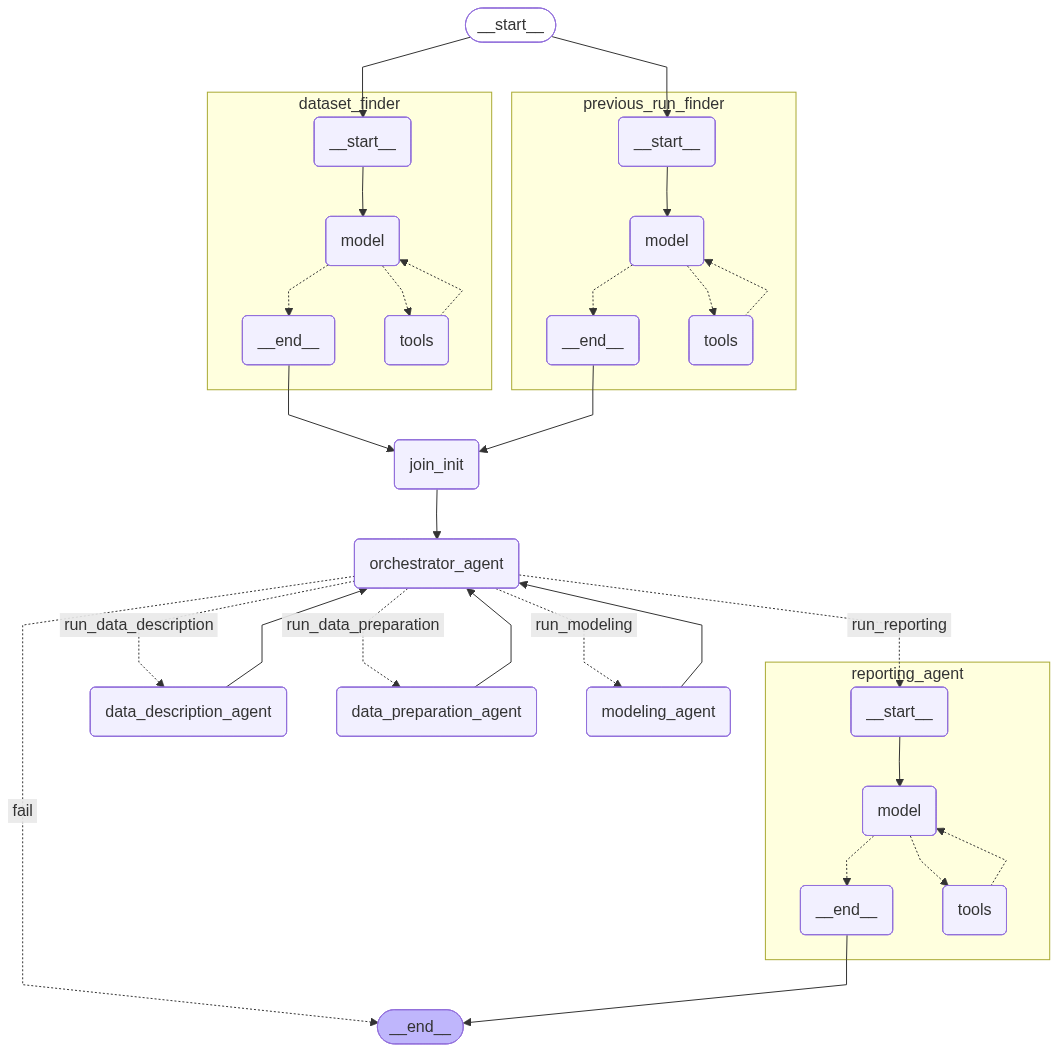

In [65]:
from IPython.display import Image, display

display(Image(full_app.get_graph(xray=True).draw_mermaid_png()))

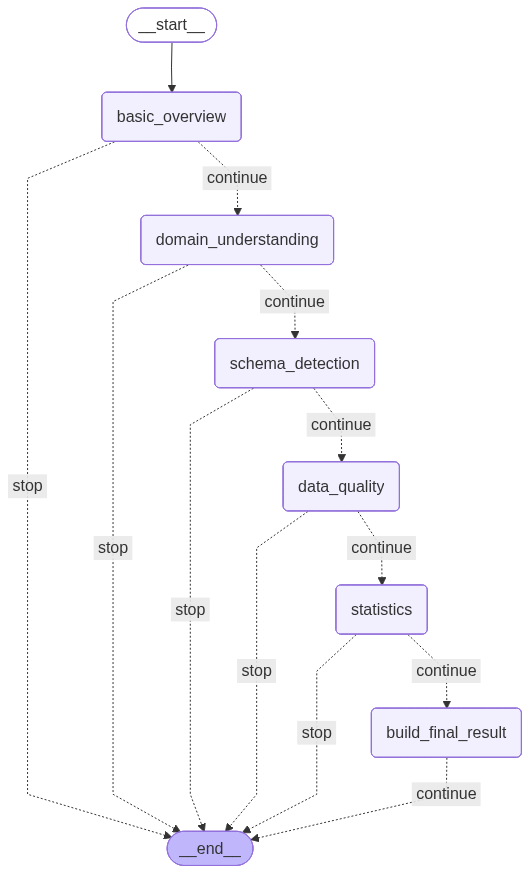

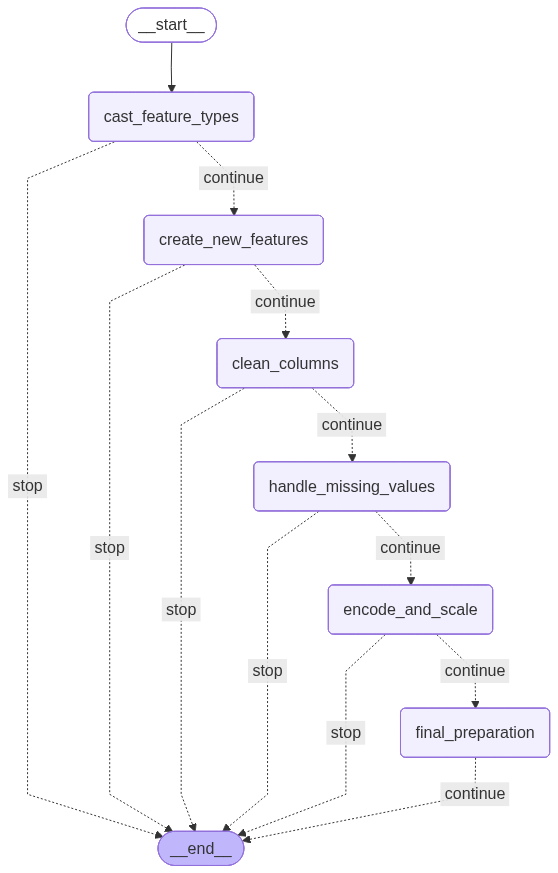

=== BUILD MODELING GRAPH ===


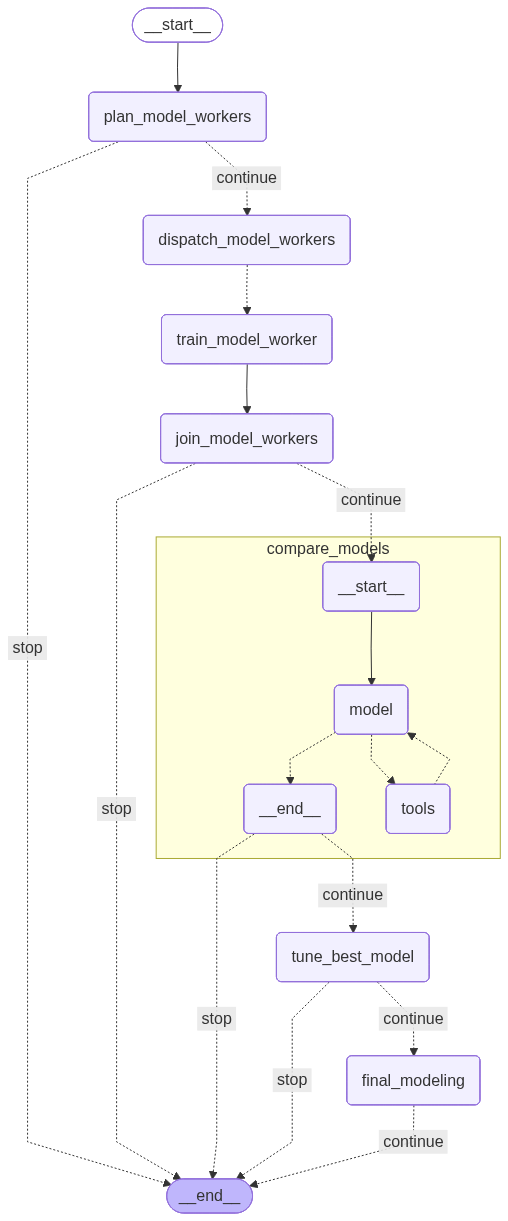

In [68]:
display(Image(build_data_description_graph().get_graph(xray=True).draw_mermaid_png()))
display(Image(build_data_preparation_graph().get_graph(xray=True).draw_mermaid_png()))
display(Image(build_modeling_graph().get_graph(xray=True).draw_mermaid_png()))